# Function 5

<b> Description of the Sample Application:</b> You’re tasked with optimising a four-variable black-box function that represents the yield of a chemical process in a factory. The function is typically unimodal, with a single peak where yield is maximised. 
Your goal is to find the optimal combination of chemical inputs that delivers the highest possible yield, using systematic exploration and optimisation methods



## Change Log

| Date | Week | Changes Made |
|---|---|---|
| 22/07/2026 | Week 1 | 1. Initial Version with 10 Data Point |
| 22/07/2026 | Week 2 | 1. Added Change Log and Progress Log.<br>2. Added new data point. |
| 05/08/2026 | Week 3 | 1. Added the Week 2 input and output.<br>2. Added RBF vs Matern(nu = 1.5) kernel comparison via log-marginal-likelihood.<br>3. Consolidated GP-fit + acquisition-optimisation into a single reusable bayesian_optimization_step() function.<br>4. Narrowed the search region to delta = 0.2 around the new best point and lowered beta from 1.8 to 1.6.<br>5. Added convergence and parallel-coordinates plots. |
| 11/08/2026 | Week 4 | 1. Recorded the Week 3 output (-1.359780), a sharp drop from Week 2's 1909.163, revealing a cliff rather than a smooth slope.<br>2. Bug Fix: np.log1p(y) is undefined for y <= -1, and Week 3's output is below -1, so the Week 1-3 pipeline would have produced NaNs from this point onward. Replaced it with a signed-log transform that handles negative outputs.<br>3. Added leave-one-out cross-validation (LOO-CV) of the GP to check calibration and overfitting.<br>4. Added an empirical check of whether a small neural network is a viable surrogate at this data size.<br>5. Re-ran the RBF vs Matern comparison post-fix and switched to a bracketed search region spanning the discovered cliff (x2 in [0.596, 0.796]), with x1/x3/x4 kept tight near the boundary. Lowered beta from 1.6 to 1.0. |
| 18/08/2026 | Week 5 | 1. Recorded the Week 4 output (1539.836) and added it to the dataset.<br>2. **Strategy change**: Week 4's result showed that x1/x3/x4 are NOT safe to hold fixed near their boundary values as previously assumed - a small move in x3 (0.999999 -> 0.9557) cost ~370 in yield even with x2 almost unchanged. Abandoned the "bracket x2 only, keep x1/x3/x4 tight" approach.<br>3. Switched to a tight local-refinement box (delta = 0.1) around the current best (Week 2's point) across **all four** dimensions, not just x2.<br>4. Lowered beta from 1.0 to 0.7 (exploit-heavy, per the 8-week plan's Week 5 target).<br>5. Re-ran the RBF vs Matern comparison and LOO-CV on the updated dataset. |
| 02/09/2026 | Week 6 | 1. Recorded the Week 5 input and output to the dataset.<br>2. **Strategy change**: plotted yield against distance from Week 2's best point across Weeks 2-5 and found a consistent, roughly monotonic decline (0.000 -> 1909.16, 0.048 -> 1539.84, 0.167 -> 706.22, 0.200 -> -1.36) as the query moves further from that corner in any of the directions tested so far. Three consecutive weeks of local refinement returning progressively worse results is a stronger signal than usual that the local neighbourhood has been adequately explored and further narrow refinement has diminishing value.<br>3. Reverted to a **full-domain search** ([0, 0.999999)^4) with beta raised back up to **2.2**, to check whether a materially better region exists elsewhere in the space rather than continuing to refine around a possibly isolated local optimum.<br>4. Re-ran the RBF vs Matern comparison and LOO-CV on the updated dataset first, to confirm the surrogate remains trustworthy before broadening the search. |
| 09/09/2026 | Week 7 | 1. Recorded the Week 6 output (68.528). The full-domain query came back low, well below the current best (1909.163), so the broad check did **not** find a better region.<br>2. **Strategy change**: Since the robustness pass found nothing better, reverted back to a tight confirmatory search (delta = 0.05, the tightest box used so far) directly around Week 2's point, with beta lowered sharply to 0.4, treating the remaining budget as a final-refinement phase rather than continued exploration.<br>3. Re-ran the RBF vs Matern comparison and LOO-CV on the updated (26-point) dataset; both improved on last week's figures. |
| 16/09/2026 | Week 8 | 1. Recorded the Week 7 output (**1915.052**). Found a **new best**, a small but genuine improvement on Week 2's 1909.163, confirming the corner region as the true local optimum.<br>2. **Strategy refinement**: comparing every query near this corner shows yield stays high only when x1 is exactly 0 and x3, x4 are exactly 0.999999 - any deviation from those three boundary values costs hundreds of points, while x2 alone has room to move (0.593-0.599) without much loss. Refined the search accordingly: x1, x3, x4 pinned tight at their apparent boundary optimum, x2 given a slightly wider band to pin down its optimum more precisely, and x4 given a very small amount of room in case it is not exactly at the boundary. Beta kept low (0.4) - continued exploitation, not a strategy reversal, since Week 7 confirmed this approach works.<br>3. Re-ran the RBF vs Matern comparison and LOO-CV on the updated (27-point) dataset. |
| 23/09/2026 | Week 9 | 1. Recorded the Week 8 output (**1825.636**), lower than Week 7's 1915.052. Moving x4 from 0.999999 down to 0.989999 (a change of only 0.01) cost ~89 yield, confirming x4 behaves exactly like x1 and x3.<br>2. **Strategy refinement**: x1, x3 **and x4** are all pinned tightly to their boundary values (0 and 0.999999 respectively); only x2 is left with meaningful room to search, in a slightly wider window than Week 8's x2 range to better resolve its optimum. Beta lowered further (0.4 to 0.3), continuing the exploitation trend now that three of four dimensions are confidently boundary-pinned.<br>3. Re-ran the RBF vs Matern comparison and LOO-CV on the updated (28-point) dataset; the sanity-check prediction for Week 8's actual point was very accurate (predicted 1827.4 vs true 1825.6), showing the surrogate has learned the x4-boundary sensitivity well. |
| 30/09/2026 | Week 10 | 1. Recorded the Week 9 output (**1912.336**), close to but slightly below the current best (1915.052). The GP's prediction at that point was 1922.02 with a very tight log-space std (0.0095, 95% CI [1886, 1958]) - the true value landed inside that band but with an error (~9.7) comparable to the reported std, a tighter miss than earlier weeks.<br>2. **Strategy refinement**: Re-ran LOO-CV on the 29-point dataset and found calibration coverage has drifted to 82.8% (below the 95% target, and the lowest of the last three weeks alongside Week 8's 75.0%) - the surrogate is somewhat overconfident overall, not just at one point. Responded by widening beta back up slightly (0.3 -> 0.5) and loosening the search bounds a little on all four dimensions (x1 upper bound 0.0005 -> 0.001, x2 window widened from [0.56, 0.64] to [0.55, 0.65], x3/x4 lower bound relaxed from 0.998 to 0.997) rather than continuing to narrow, to avoid over-committing to an overconfident region with only 2 queries left after this one.<br>3. Re-ran the RBF vs Matern comparison on the updated (29-point) dataset; RBF remains the better fit. |

# Progress Log

| Week | Query Point (x1, x2, x3, x4) | Output (y) | Best y so far | β (kappa) | Search region | Notes |
|---|---|---|---|---|---|---|
|  |  |  |  |  |  |  |
| **Week 1** | 0.037439-0.014236-0.070689-0.986304 | 154.182426 | 1088.860 (unchanged) | 2.5 | full [0, 1)^4 | Deliberately exploratory corner query (high β, sparse 4D coverage). GP had predicted ≈3464.8 in log-space back-transform; true yield was far lower — a sign the RBF surrogate was overconfident extrapolating into an unseen corner. |
| **Week 2** | 0.000000-0.596480-0.999999-0.999999 | 1909.163378 | 1909.163 (New Best) | 1.8 | narrowed box: +-0.25 around Week 1's best | Beat the previous best by ~75%. Predicted mean was 2188.6, which is much closer to the true value than Week 1's miss, showing the narrower box + lower beta improved calibration. |
| **Week 3** | 0.000000-0.796480-0.999999-0.999999 | -1.359780 | 1909.163 (unchanged) | 1.6 | narrowed box: +/-0.2 around Week 2's best | Predicted mean was +2874.5 - a huge miss. Pushing x2 further in the same direction that worked in Week 2 crashed the output from 1909 to negative, revealing a sharp cliff between x2 = 0.596 and x2 = 0.796, not a smooth slope. This also exposed a pipeline bug (see Change Log) since y < -1 breaks log1p. |
| **Week 4** | 0.018201-0.598992-0.955729-0.998108 | **1539.836198** | 1909.163 (unchanged) | 1.0 | bracketed box: x2 in [0.596, 0.796]; x1, x3, x4 tight near boundary | Small moves in x1 (0 -> 0.018) and x3 (0.999999 -> 0.9557), with x2 almost unchanged, cost ~370 in yield - shows x1/x3/x4 matter too, not just x2. Prompted the Week 5 strategy change below. |
| **Week 5** | 0.100000-0.593535-0.899999-0.911213 | **706.215780** | 1909.163 (unchanged) | 0.7 | tight box: delta = 0.1 around Week 2's best, all 4 dims | A larger move away from the corner (distance 0.167 vs Week 4's 0.048) cost even more yield (706 vs 1539) - the decline is tracking distance from the corner. |
| **Week 6** | 0.437120-0.835366-0.700265-0.312367 | **68.527533** | 1909.163 (unchanged) | 2.2 | full domain [0, 0.999999)^4 | Robustness check: a genuinely different region, chosen for high uncertainty. Came back low - did not beat the current best. |
| **Week 7** | 0.000000-0.599413-0.999999-0.999999 | **1915.052203** | **1915.052 (NEW BEST)** | 0.4 | very tight box: delta = 0.05 around Week 2's best | Confirmatory refinement paid off - a small genuine improvement, confirming this corner as the true local optimum. |
| **Week 8** | 0.000000-0.599054-0.999999-0.989999 | 1825.635632 | 1915.052 (unchanged) | 0.4 | near-1D: x1/x3 pinned, x2 free, x4 in [0.99, 0.999999] | Testing x4's boundary sensitivity backfired slightly - a 0.01 move in x4 cost ~89 yield, confirming x4 also wants the exact boundary value. |
| **Week 9** | 0.000418-0.598066-0.999999-0.999999 | 1912.336204 | 1915.052 (unchanged) | 0.3 | **near-1D refinement**: x1, x3, x4 all tightly pinned to boundary; x2 free in a slightly wider window | Week 8 confirmed all three of x1/x3/x4 are boundary-pinned; only x2 has genuine room left. This is a final push to resolve x2's precise optimum with three of four dimensions now confidently fixed. |
| **Week 10** | 0.000000-0.599863-0.999999-0.999999 | *(pending)* | 1915.052 (unchanged) | 0.5 | widened near-1D box: x1 in [0, 0.001], x2 in [0.55, 0.65], x3/x4 in [0.997, 0.999999] | Full-dataset LOO-CV coverage dropped to 82.8% (below the 95% target) - beta raised (0.3 -> 0.5) and bounds loosened slightly on all 4 dims in response, rather than narrowing further, with only 2 queries left after this one. |

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel, Matern
from sklearn.neural_network import MLPRegressor
from scipy.optimize import minimize
import warnings
warnings.filterwarnings("ignore")

from plotting_utils import plot_convergence, plot_parallel_coordinates

# Load and Analyse the Data

In [9]:
# File Names
input_file  = "initial_inputs.npy"
output_file = "initial_outputs.npy"

# Load the Files
X0      = np.load(input_file)
Y0      = np.load(output_file)

In [10]:
# New data from the first submission (example inputs and outputs)
X_w1_new_point = np.array([0.037439, 0.014236, 0.070689, 0.986304]   , dtype=np.float64)    # from input.txt
Y_w1_new_point = np.array([154.18242633803845]                       , dtype=np.float64)    # from output.txt


# New data from Week 2 submission
X_w2_new_point = np.array([0.      , 0.59648 , 0.999999, 0.999999]     , dtype=np.float64)    # from input.txt
Y_w2_new_point = np.array([1909.163378175112]                          , dtype=np.float64)    # from output.txt

# New data from Week 3 submission
X_w3_new_point = np.array([0.      , 0.79648 , 0.999999, 0.999999]     , dtype=np.float64)    # from input.txt
Y_w3_new_point = np.array([-1.359780271551876]                         , dtype=np.float64)    # from output.txt

# New data from Week 4 submission
X_w4_new_point = np.array([0.018201, 0.598992, 0.955729, 0.998108]     , dtype=np.float64)    # from input.txt
Y_w4_new_point = np.array([1539.8361979432834]                         , dtype=np.float64)    # from output.txt

# New data from Week 5 submission
X_w5_new_point = np.array([0.1     , 0.593535, 0.899999, 0.911213]     , dtype=np.float64)    # from input.txt
Y_w5_new_point = np.array([706.2157796732383]                          , dtype=np.float64)    # from output.txt

# New data from Week 6 submission
X_w6_new_point = np.array([0.43712 , 0.835366, 0.700265, 0.312367]     , dtype=np.float64)    # from input.txt
Y_w6_new_point = np.array([68.52753287272596]                          , dtype=np.float64)    # from output.txt

# New data from Week 7 submission
X_w7_new_point = np.array([0.      , 0.599413, 0.999999, 0.999999]     , dtype=np.float64)    # from input.txt
Y_w7_new_point = np.array([1915.0522026721717]                         , dtype=np.float64)    # from output.txt

# New data from Week 8 submission
X_w8_new_point = np.array([0.      , 0.599054, 0.999999, 0.989999]     , dtype=np.float64)    # from input.txt
Y_w8_new_point = np.array([1825.635632307651]                          , dtype=np.float64)    # from output.txt

# New data from Week 9 submission
X_w9_new_point = np.array([0.000418, 0.598066, 0.999999, 0.999999]     , dtype=np.float64)    # from input.txt
Y_w9_new_point = np.array([1912.3362038947155]                         , dtype=np.float64)    # from output.txt

In [13]:
# Append the new data points
X_updated      = np.vstack((X0, X_w1_new_point
                              , X_w2_new_point
                              , X_w3_new_point    
                              , X_w4_new_point
                              , X_w5_new_point
                              , X_w6_new_point
                              , X_w7_new_point
                              , X_w8_new_point
                              , X_w9_new_point
                           ))
Y_updated      = np.append(Y0, [Y_w1_new_point
                             , Y_w2_new_point
                             , Y_w3_new_point 
                             , Y_w4_new_point
                             , Y_w5_new_point
                             , Y_w6_new_point
                             , Y_w7_new_point
                             , Y_w8_new_point
                             , Y_w9_new_point
                              ])


In [16]:
print(X_updated)
print(Y_updated)

# Save the updated arrays
#np.save(r"initial_inputs.npy", X_updated)
#np.save(r"initial_outputs.npy", Y_updated)

[[1.91447084e-01 3.81933714e-02 6.07417811e-01 4.14584137e-01]
 [7.58652949e-01 5.36517738e-01 6.56000382e-01 3.60341553e-01]
 [4.38349873e-01 8.04339705e-01 2.10245266e-01 1.51294816e-01]
 [7.06050834e-01 5.34191961e-01 2.64243345e-01 4.82087549e-01]
 [8.36477993e-01 1.93609647e-01 6.63892697e-01 7.85648883e-01]
 [6.83432250e-01 1.18662642e-01 8.29045910e-01 5.67576606e-01]
 [5.53621480e-01 6.67349979e-01 3.23805819e-01 8.14869754e-01]
 [3.52356269e-01 3.22241532e-01 1.16979368e-01 4.73112522e-01]
 [1.53785706e-01 7.29381690e-01 4.22598437e-01 4.43074166e-01]
 [4.63442267e-01 6.30024510e-01 1.07906456e-01 9.57643899e-01]
 [6.77491148e-01 3.58509507e-01 4.79592224e-01 7.28804811e-02]
 [5.83973412e-01 1.47242646e-01 3.48097462e-01 4.28614651e-01]
 [3.06888719e-01 3.16878127e-01 6.22634481e-01 9.53990581e-02]
 [5.11141775e-01 8.17956997e-01 7.28710418e-01 1.12353623e-01]
 [4.38933376e-01 7.74091762e-01 3.78167086e-01 9.33696207e-01]
 [2.24189023e-01 8.46480490e-01 8.79484180e-01 8.785156

In [18]:
# Assign X = X_updated and Y = Y_updated
X          = X_updated
Y          = Y_updated

# Analyse the Input Data
print("Input  Shape:", X.shape)
print("Inputs:\n", X)
print()

# Analyse the Output Data
print("Output Shape:", Y.shape)
print("Outputs:\n", Y)
print()

print(f"Y Range: [: {Y.min()}, {Y.max()}]")
best_idx   = np.argmax(Y)
print(f"Best point: X = {X[best_idx]}, Y = {Y[best_idx]}")
print()

# Converting the Input and Output into a DataFram
df         = pd.DataFrame(X, columns = [f'X_{i+1}' for i in range(X.shape[1])])
df['Y'] = Y
print("Data Frame:\n", df)


Input  Shape: (29, 4)
Inputs:
 [[1.91447084e-01 3.81933714e-02 6.07417811e-01 4.14584137e-01]
 [7.58652949e-01 5.36517738e-01 6.56000382e-01 3.60341553e-01]
 [4.38349873e-01 8.04339705e-01 2.10245266e-01 1.51294816e-01]
 [7.06050834e-01 5.34191961e-01 2.64243345e-01 4.82087549e-01]
 [8.36477993e-01 1.93609647e-01 6.63892697e-01 7.85648883e-01]
 [6.83432250e-01 1.18662642e-01 8.29045910e-01 5.67576606e-01]
 [5.53621480e-01 6.67349979e-01 3.23805819e-01 8.14869754e-01]
 [3.52356269e-01 3.22241532e-01 1.16979368e-01 4.73112522e-01]
 [1.53785706e-01 7.29381690e-01 4.22598437e-01 4.43074166e-01]
 [4.63442267e-01 6.30024510e-01 1.07906456e-01 9.57643899e-01]
 [6.77491148e-01 3.58509507e-01 4.79592224e-01 7.28804811e-02]
 [5.83973412e-01 1.47242646e-01 3.48097462e-01 4.28614651e-01]
 [3.06888719e-01 3.16878127e-01 6.22634481e-01 9.53990581e-02]
 [5.11141775e-01 8.17956997e-01 7.28710418e-01 1.12353623e-01]
 [4.38933376e-01 7.74091762e-01 3.78167086e-01 9.33696207e-01]
 [2.24189023e-01 8.46480

# Data Exploration

In [21]:
# Basic Staistics
print("Display Basic Statistics for the Dataset\n",df.describe())

Display Basic Statistics for the Dataset
              X_1        X_2        X_3        X_4            Y
count  29.000000  29.000000  29.000000  29.000000    29.000000
mean    0.337963   0.524233   0.592605   0.623875   450.173348
std     0.274539   0.260425   0.313983   0.342904   681.054878
min     0.000000   0.014236   0.070689   0.072880    -1.359780
25%     0.100000   0.322242   0.348097   0.360342    28.866752
50%     0.352356   0.598066   0.643331   0.759760    78.434389
75%     0.553621   0.729382   0.879484   0.957644   431.612757
max     0.836478   0.862540   0.999999   0.999999  1915.052203


In [23]:
# Check for Missing Values in the Data Set
print("Missing Values in the Dataset\n",df.isnull().sum())

Missing Values in the Dataset
 X_1    0
X_2    0
X_3    0
X_4    0
Y      0
dtype: int64


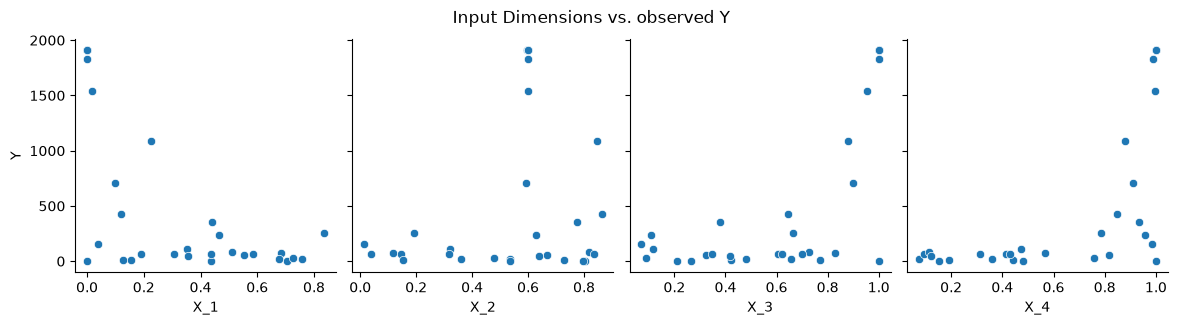

In [25]:
# Pairwise Scatter Plot, showing relationship of y for each input
sns.pairplot(df, y_vars = ['Y'], x_vars = ['X_1', 'X_2', 'X_3', 'X_4'], height = 3)
plt.suptitle("Input Dimensions vs. observed Y", y = 1.05)
plt.show()

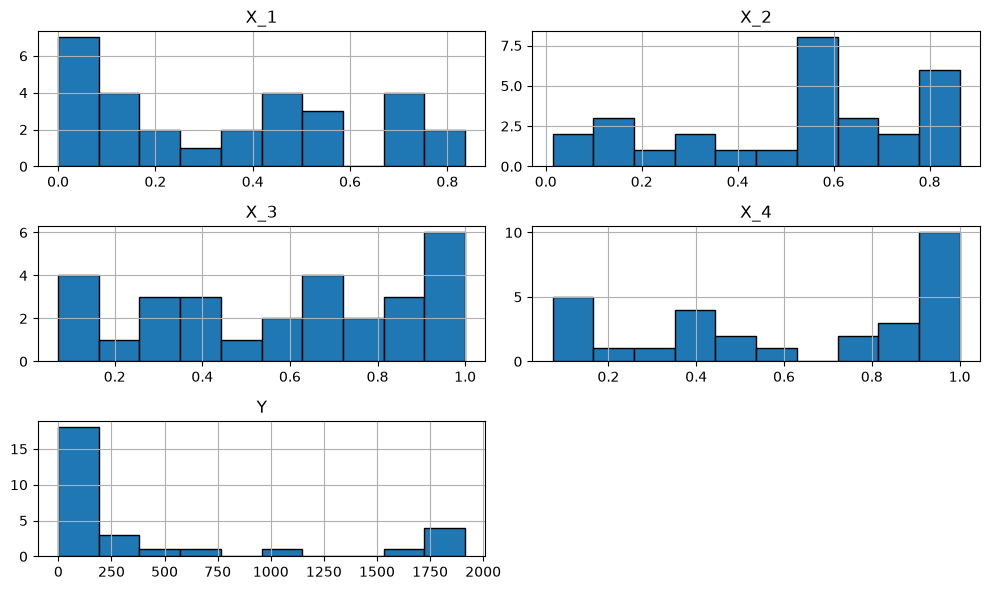

In [27]:
# Plot Histogram Visualisation for the columns of the DataFrame
df.hist(figsize = (10, 6), bins = 10, edgecolor = 'k' )
plt.tight_layout()
plt.show()

In [29]:
# Understanding Correlation between each input with y
labels      = ["X_1", "X_2", "X_3", "X_4"]
print("Correlation of each input with Y:\n")

for i, lab in enumerate(labels):
    corr = np.corrcoef(X[:, i], Y)[0, 1]
    print(f" corr({lab}, Y) = {corr}")

Correlation of each input with Y:

 corr(X_1, Y) = -0.609960616223605
 corr(X_2, Y) = 0.2211696866037133
 corr(X_3, Y) = 0.6464163449148399
 corr(X_4, Y) = 0.6254783089583472


<Axes: >

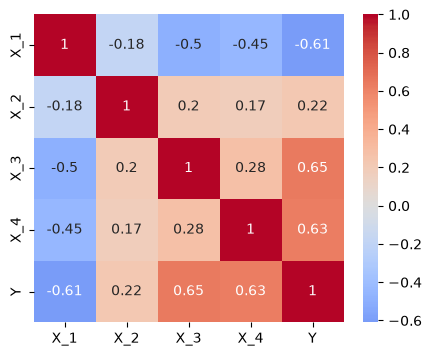

In [31]:
# Plotting the Correlation heatmap
plt.figure(figsize = (5, 4))
sns.heatmap(df.corr(), annot = True, cmap = "coolwarm", center = 0)

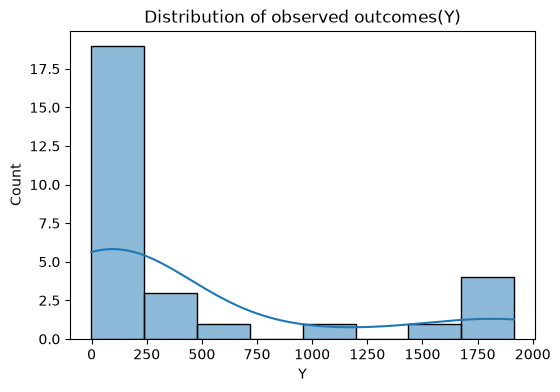

In [33]:
# Plot the Histogram for y to check for Outliers
plt.figure(figsize = (6,4))
sns.histplot(df['Y'], kde = True)
plt.title("Distribution of observed outcomes(Y)")
plt.show()

# Initialize Gaussian Process
Keeping the **RBF** kernel for Week 2 as well, as with only 21 points in 4D the isn't yet enough evidence to justify a rougher kernel like Matern 0.5.
As in Week 1, modelling log1p(Y) rather than raw Y, since the output still spans roughly 3 orders of magnitude (0.11 to ~ 1089) and a plain GP would let the largest values dominate the length-scale/variance fit.ce fit.

In [36]:
#Define the kernel and initialise the GP model

kernel_rbf = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = [1.0] * 4, length_scale_bounds = (1e-2, 1e2)) \
                + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-5, 1e0))
gpr   = GaussianProcessRegressor(kernel = kernel_rbf, normalize_y = False, n_restarts_optimizer = 10, random_state = 42 )

# Bug Fix ( Week 4 )
Week 3's output was **-1.359780**, which is **below -1**. np.log1p(y) = log(1 + y) is only defined for y > -1; for y <= -1, 1 + y <= 0 and the log is undefined.
Hence, np.log1p(-1.36) returns **NaN**. Since log1p(Y) was modelled since Week 1, this would break the surrogate fit from this point on.

**Fix**: switch to a *signed*-log transform, which compresses large magnitudes the same way log1p did but is defined for the full real line:
```
signed_log1p(y) = sign(y) * log1p( | y | )
inverse         = sign(z) * expm1( | z | )
```
This fix is applied everywhere log1p/expm1 were previously used: the main GP fit below, predict_yield() and inside bayesian_optimization_step().

In [39]:
def signed_log1p(y):
    """Like log1p, but defined for the full real line (handles y <= -1)."""
    return np.sign(y) * np.log1p(np.abs(y))

def inverse_signed_log1p(z):
    """Inverse of signed_log1p."""
    return np.sign(z) * np.expm1(np.abs(z))

# Demonstrate the bug and the fix on Week 3's actual output:
print("Old np.log1p(-1.359780)      :", np.log1p(-1.359780271551876), " <- NaN, this is the bug")
print("New signed_log1p(-1.359780)  :", signed_log1p(-1.359780271551876))
print("Round-trip check             :", inverse_signed_log1p(signed_log1p(-1.359780271551876)))

Old np.log1p(-1.359780)      : nan  <- NaN, this is the bug
New signed_log1p(-1.359780)  : -0.8585685094283249
Round-trip check             : -1.3597802715518763


# Fit the Gaussian Processes to existing data

In [42]:
# y is spread beyond 1000, If we model with raw values of y, couple of large values dominate the Gaussian Processes' length-scale/variance fit
# Hence, modelling  log1p(y) rather than raw y. Working in log-space keeps the regression well-conditioned

X_scaler       = StandardScaler()
X_s            = X_scaler.fit_transform(X)

Y_log          = signed_log1p(Y)       # np.log1p(Y) Bug Fix ( Week 4 )
Y_mean, Y_std  = Y_log.mean(), Y_log.std()
Y_s            = (Y_log - Y_mean) / Y_std

# Train the model

gpr.fit(X_s, Y_s)
print("Learned kernel: ", gpr.kernel_)

Learned kernel:  0.934**2 * RBF(length_scale=[0.62, 0.265, 1.36, 1.16]) + WhiteKernel(noise_level=1e-05)


# Compute the UCB acquisition function

- UCB(x)=μ(x)+β⋅σ(x)
- A high beta favors exploration (uncertainty) over exploitation (predicted mean).
- Week 1 uses beta = 2.5, reflecting the 90:10 exploration-heavy strategy.

In [46]:
# Function to predict mean and std for raw x
def predict_yield(X_raw):
    Xs          = X_scaler.transform(X_raw)
    mu_s, std_s = gpr.predict(Xs, return_std = True)
    mu_log      = mu_s * Y_std + Y_mean
    std_log     = std_s * Y_std
    #mu_yield    = np.expm1(mu_log)    # Bug Fix ( Week 4 )
    mu_yield    = inverse_signed_log1p(mu_log)
    return mu_yield, std_log

# Setting a higher beta(= 2.5) for Week -1
#beta         = 2.5                

# Setting a higher beta(= 1.8) for Week -8
beta         = 1.8  

# Function to calculare UCB 
def ucb_log_space(X_raw, beta = beta):
    Xs          = X_scaler.transform(X_raw)
    mu_s, std_s = gpr.predict(Xs, return_std = True)
    return mu_s + beta * std_s

# Commented Code for Week 1 
# n_candidates = 200000
# RNG          = np.random.default_rng(42)
# candidates   = RNG.uniform(0, 1, size = (n_candidates, 4))

# ucb_scores   = ucb_log_space(candidates)
# next_idx     = np.argmax(ucb_scores)
# x_next       = candidates[next_idx]

# pred_mu, pred_std_log = predict_yield(x_next.reshape(1, -1))

# print(f"Suggested next Query Point: {x_next}")
# print(f"Predicted Mean(μ): {pred_mu[0]:.6e}")
# print(f"Predicted Std (σ): {pred_std_log[0]:.6e}")
# print(f"UCB Score: {ucb_scores[next_idx]:.6e}")


# Week 2: Consolidated Bayesian Optimisation Function
Define a consolidated function that includes acquisition optimisation into a single reusable function. Two changes from Week 1's approach:

- **Multi-start L-BFGS-B** on the negative UCB, instead of scoring 200,000 random candidates and taking the arg-max. This locates the acquisition optimum more precisely, as the search area becomes smaller.
- The function accepts explicit **bounds**, so it can be reused for the narrowed region this week and for the full `[0,1)^4` cube in earlier/future weeks alike.

In [49]:
def suggest_next_query(gpr, X_scaler, Y_mean, Y_std, bounds, beta = 1.8, n_restarts = 25, seed = 42):
    rng      = np.random.default_rng(seed)
    dim      = bounds.shape[0]

    def neg_acq(x):
        x           = x.reshape(1, -1)
        Xs          = X_scaler.transform(x)
        mu_s, std_s = gpr.predict(Xs, return_std = True)
        return -(mu_s[0] + beta * std_s[0])

    best_val, best_x = np.inf, None
    starts           = rng.uniform(bounds[:, 0], bounds[:, 1], size = (n_restarts, dim))
    for x0 in starts:
        res          = minimize(neg_acq, x0, bounds = list(zip(bounds[:, 0], bounds[:, 1])), method = "L-BFGS-B")
        if res.fun < best_val:
            best_val, best_x = res.fun, res.x

    mu_next, std_next = predict_yield(best_x.reshape(1, -1))
    return best_x, mu_next[0], std_next[0], -best_val


# Narrow the search region and run the Week 2 query


In [52]:
# Restricting the candidate search to a box of half-width **0.25** around the current best point.
delta      = 0.25
best_x_now = X[best_idx]

lb         = np.clip(best_x_now - delta, 0.0, 0.999999)
ub         = np.clip(best_x_now + delta, 0.0, 0.999999)
bounds     = np.vstack([lb, ub]).T
print("Narrowed search bounds (per dimension):\n", bounds)

x_next, pred_mu, pred_std_log, ucb_next = suggest_next_query(gpr, X_scaler, Y_mean, Y_std, bounds, beta = beta)

print(f"\nSuggested next Query Point: {np.round(x_next, 6)}")
print(f"Predicted Mean (μ)          : {pred_mu:.4f}")
print(f"Predicted Std (σ, log-space): {pred_std_log:.4f}")
print(f"UCB Score                   : {ucb_next:.4f}")

Narrowed search bounds (per dimension):
 [[0.       0.25    ]
 [0.349413 0.849413]
 [0.749999 0.999999]
 [0.749999 0.999999]]

Suggested next Query Point: [0.25     0.849413 0.749999 0.999999]
Predicted Mean (μ)          : 1491.2189
Predicted Std (σ, log-space): 0.8513
UCB Score                   : 1.9893


# Perform Visualisation ( Week 1 )

Full 4D UCB surface can't be drawn directly. Hence, we visualise 2D slices for every pair of dimensions, fix the other two dimensions at the current
best-known x, and sweep a grid over the chosen pair. This shows how UCB (and mu, sigma) behave locally around the best point found so far.

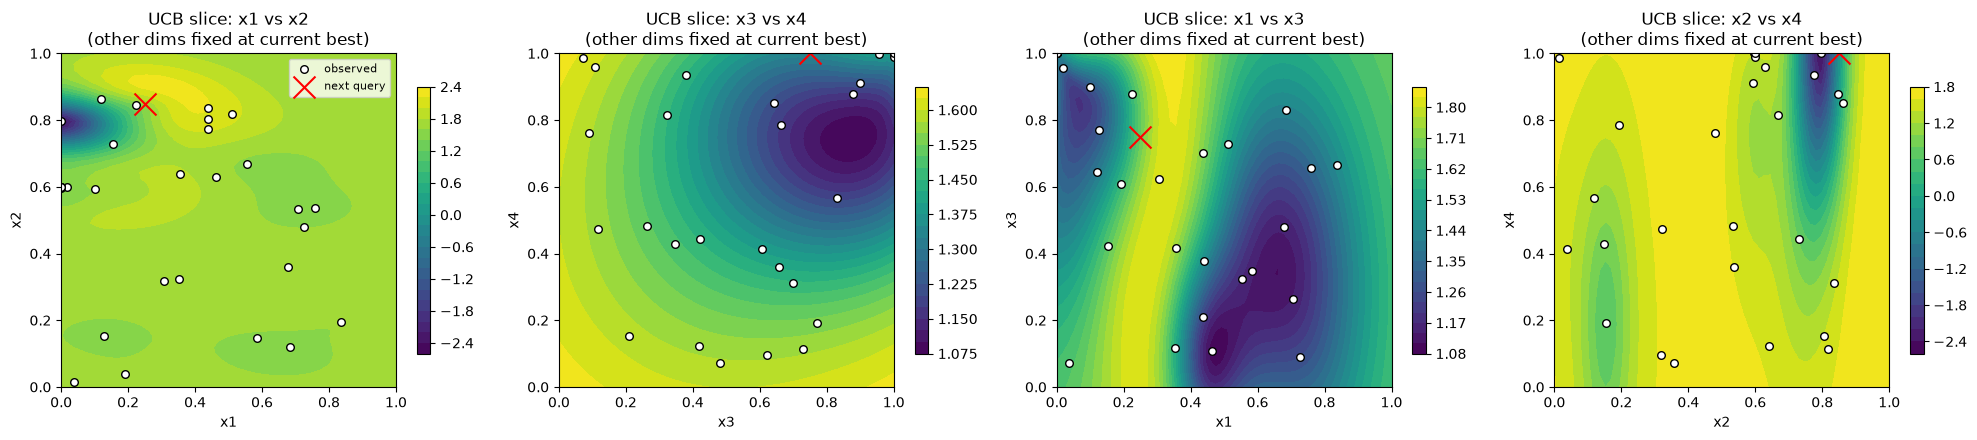

In [56]:
grid_n = 60
grid_1d = np.linspace(0, 1, grid_n)
pairs = [(0, 1), (2, 3), (0, 2), (1, 3)]
fixed_point = X[best_idx].copy()  # anchor the other two dims here
 
fig, axes = plt.subplots(1, len(pairs), figsize=(5 * len(pairs), 4.5))
for ax, (d1, d2) in zip(axes, pairs):
    A, B = np.meshgrid(grid_1d, grid_1d)
    grid_points = np.tile(fixed_point, (grid_n * grid_n, 1))
    grid_points[:, d1] = A.ravel()
    grid_points[:, d2] = B.ravel()
 
    scores = ucb_log_space(grid_points).reshape(grid_n, grid_n)
    im = ax.contourf(A, B, scores, levels=25, cmap="viridis")
    ax.scatter(X[:, d1], X[:, d2], c="white", edgecolor="black", s=30, label="observed")
    ax.scatter(x_next[d1], x_next[d2], c="red", marker="x", s=250, label="next query")
    ax.set_xlabel(f"x{d1+1}")
    ax.set_ylabel(f"x{d2+1}")
    ax.set_title(f"UCB slice: x{d1+1} vs x{d2+1}\n(other dims fixed at current best)")
    fig.colorbar(im, ax=ax, shrink=0.8)
axes[0].legend(loc="upper right", fontsize=8)
plt.tight_layout()

# Week 2: UCB Visualisation ( Zoomed to the narrowed region )
This week zoomed into the narrowed box rather than the full unit cube, so the local structure around the current best is visible in more detail.l.

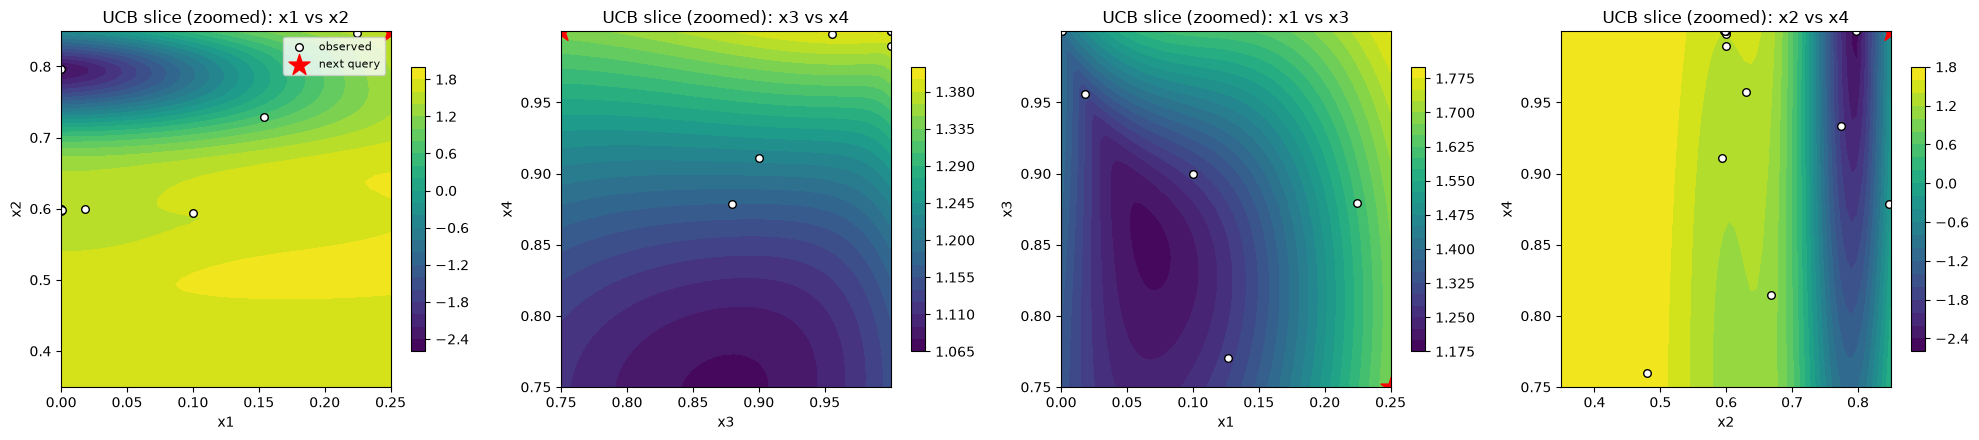

In [58]:
grid_n          = 60
pairs           = [(0, 1), (2, 3), (0, 2), (1, 3)]
fixed_point     = best_x_now.copy()

fig, axes       = plt.subplots(1, len(pairs), figsize = (5 * len(pairs), 4.5))
for ax, (d1, d2) in zip(axes, pairs):
    g1          = np.linspace(bounds[d1, 0], bounds[d1, 1], grid_n)
    g2          = np.linspace(bounds[d2, 0], bounds[d2, 1], grid_n)
    A, B        = np.meshgrid(g1, g2)
    grid_points = np.tile(fixed_point, (grid_n * grid_n, 1))
    grid_points[:, d1] = A.ravel()
    grid_points[:, d2] = B.ravel()

    scores = ucb_log_space(grid_points, beta).reshape(grid_n, grid_n)
    im = ax.contourf(A, B, scores, levels = 25, cmap = "viridis")
    ax.scatter(X[:, d1], X[:, d2], c = "white", edgecolor = "black", s = 30, label = "observed")
    ax.scatter(x_next[d1], x_next[d2], c = "red", marker = "*", s = 250, label = "next query")
    ax.set_xlim(bounds[d1, 0], bounds[d1, 1])
    ax.set_ylim(bounds[d2, 0], bounds[d2, 1])
    ax.set_xlabel(f"x{d1+1}")
    ax.set_ylabel(f"x{d2+1}")
    ax.set_title(f"UCB slice (zoomed): x{d1+1} vs x{d2+1}")
    fig.colorbar(im, ax = ax, shrink = 0.8)
axes[0].legend(loc="upper right", fontsize = 8)
plt.tight_layout()
plt.show()


# Week 3: Kernel Comparison ( RBF vs Matern )

In [62]:
# Week 3: Kernel Comparison
gpr_rbf       = gpr   

kernel_matern = ConstantKernel(1.0, (1e-2, 1e2)) * Matern(length_scale = [1.0] * 4, length_scale_bounds = (1e-2, 1e2), nu = 1.5) \
                  + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-5, 1e0))

gpr_matern = GaussianProcessRegressor(kernel = kernel_matern, normalize_y = False, n_restarts_optimizer = 10, random_state = 42)
gpr_matern.fit(X_s, Y_s)

lml_rbf    = gpr_rbf.log_marginal_likelihood(gpr_rbf.kernel_.theta)
lml_matern = gpr_matern.log_marginal_likelihood(gpr_matern.kernel_.theta)

print(f"RBF    kernel            : {gpr_rbf.kernel_}")
print(f"  Log-marginal-likelihood: {lml_rbf:.3f}")
print(f"Matern kernel            : {gpr_matern.kernel_}")
print(f"  Log-marginal-likelihood: {lml_matern:.3f}")

# Keep whichever kernel fits the data better (Choose kernel with igher log-marginal-likelihood)
if lml_matern > lml_rbf:
    gpr           = gpr_matern
    chosen_kernel = "Matern(nu=1.5)"
else:
    gpr           = gpr_rbf
    chosen_kernel = "RBF"

print(f"\nWeek 3 kernel choice: {chosen_kernel} (Choose kernel with higher log-marginal-likelihood )")


RBF    kernel            : 0.934**2 * RBF(length_scale=[0.62, 0.265, 1.36, 1.16]) + WhiteKernel(noise_level=1e-05)
  Log-marginal-likelihood: -21.661
Matern kernel            : 0.942**2 * Matern(length_scale=[0.755, 0.299, 1.83, 1.46], nu=1.5) + WhiteKernel(noise_level=1e-05)
  Log-marginal-likelihood: -23.771

Week 3 kernel choice: RBF (Choose kernel with higher log-marginal-likelihood )


# Week 3: Consolidated Bayesian Optimisation Function

In [65]:
def bayesian_optimization_step(X, Y, bounds, beta = 1.6, kernel_type = "rbf", n_restarts_gp = 10, n_restarts_acq = 25, seed = 42):
    X_scaler_l = StandardScaler()
    X_s_l      = X_scaler_l.fit_transform(X)
    #Y_log_l    = np.log1p(Y)     # Commented for Bug Fix ( Week 4 )
    Y_log_l    = signed_log1p(Y)  # Added for Week 4 Bug Fix
    Y_mean_l, Y_std_l = Y_log_l.mean(), Y_log_l.std()
    Y_s_l      = (Y_log_l - Y_mean_l) / Y_std_l

    if kernel_type == "rbf":
        kernel_l = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = [1.0] * X.shape[1], length_scale_bounds = (1e-2, 1e2)) \
                   + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-5, 1e0))
    elif kernel_type == "matern":
        kernel_l = ConstantKernel(1.0, (1e-2, 1e2)) * Matern(length_scale = [1.0] * X.shape[1], length_scale_bounds = (1e-2, 1e2), nu = 1.5) \
                   + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-5, 1e0))
    else:
        raise ValueError("kernel_type must be 'rbf' or 'matern'")

    gpr_l = GaussianProcessRegressor(kernel = kernel_l, normalize_y = False, n_restarts_optimizer = n_restarts_gp, random_state = seed)
    gpr_l.fit(X_s_l, Y_s_l)
    lml_l = gpr_l.log_marginal_likelihood(gpr_l.kernel_.theta)

    def predict_yield_l(X_raw):
        Xs = X_scaler_l.transform(X_raw)
        mu_s, std_s = gpr_l.predict(Xs, return_std = True)
        mu_log      = mu_s * Y_std_l + Y_mean_l
        std_log     = std_s * Y_std_l
        #return np.expm1(mu_log), std_log              # Commented for Bug Fix ( Week 4 )
        return inverse_signed_log1p(mu_log), std_log   # Added for Bug Fix ( Week 4 )

    rng = np.random.default_rng(seed)
    dim = bounds.shape[0]

    def neg_acq(x):
        x = x.reshape(1, -1)
        Xs = X_scaler_l.transform(x)
        mu_s, std_s = gpr_l.predict(Xs, return_std = True)
        return -(mu_s[0] + beta * std_s[0])

    best_val, best_x = np.inf, None
    starts = rng.uniform(bounds[:, 0], bounds[:, 1], size = (n_restarts_acq, dim))
    for x0 in starts:
        res = minimize(neg_acq, x0, bounds = list(zip(bounds[:, 0], bounds[:, 1])), method = "L-BFGS-B")
        if res.fun < best_val:
            best_val, best_x = res.fun, res.x

    mu_next, std_next = predict_yield_l(best_x.reshape(1, -1))

    return {
        "kernel_type": kernel_type, "gpr": gpr_l, "X_scaler": X_scaler_l,
        "Y_mean": Y_mean_l, "Y_std": Y_std_l, "log_marginal_likelihood": lml_l,
        "x_next": best_x, "mu_next": mu_next[0], "std_next": std_next[0],
        "ucb_next": -best_val,
    }

# --- Narrow the search region around the CURRENT best (now Week 2's point) ---
delta      = 0.2                                     # Week 3 delta reduced from 0.25 to 0.2
best_idx   = np.argmax(Y)                            # recompute in case data changed above
best_x_now = X[best_idx]

lb         = np.clip(best_x_now - delta, 0.0, 0.999999)
ub         = np.clip(best_x_now + delta, 0.0, 0.999999)
bounds     = np.vstack([lb, ub]).T
print("Week 3 narrowed search bounds (per dimension):\n", bounds)

beta = 1.6                                           # Week 3: beta reduced from 1.8 to 1.6 to facilitate exploitation

# Check Kernel best-fit
result_rbf    = bayesian_optimization_step(X, Y, bounds, beta = beta, kernel_type = "rbf")
result_matern = bayesian_optimization_step(X, Y, bounds, beta = beta, kernel_type = "matern")

print(f"bayesian_optimization_step RBF LML     : {result_rbf['log_marginal_likelihood']:.3f}")
print(f"bayesian_optimization_step Matern LML  : {result_matern['log_marginal_likelihood']:.3f}")

final = result_matern if result_matern["log_marginal_likelihood"] > result_rbf["log_marginal_likelihood"] else result_rbf


gpr             = final["gpr"]
X_scaler        = final["X_scaler"]
Y_mean          = final["Y_mean"]
Y_std           = final["Y_std"]
x_next          = final["x_next"]
pred_mu         = final["mu_next"]
pred_std_log    = final["std_next"]
ucb_next        = final["ucb_next"]

print(f"\nWeek 3 chosen kernel      : {final['kernel_type']}")
print(f"Suggested next Query Point  : {np.round(x_next, 6)}")
print(f"Predicted Mean (mu)         : {pred_mu:.4f}")
print(f"Predicted Std (sigma, log)  : {pred_std_log:.4f}")
print(f"UCB Score                   : {ucb_next:.4f}")

Week 3 narrowed search bounds (per dimension):
 [[0.       0.2     ]
 [0.399413 0.799413]
 [0.799999 0.999999]
 [0.799999 0.999999]]
bayesian_optimization_step RBF LML     : -21.661
bayesian_optimization_step Matern LML  : -23.771

Week 3 chosen kernel      : rbf
Suggested next Query Point  : [0.2      0.523591 0.999999 0.999999]
Predicted Mean (mu)         : 284.4443
Predicted Std (sigma, log)  : 1.6035
UCB Score                   : 1.7005


# Week 3: UCB Visualisation

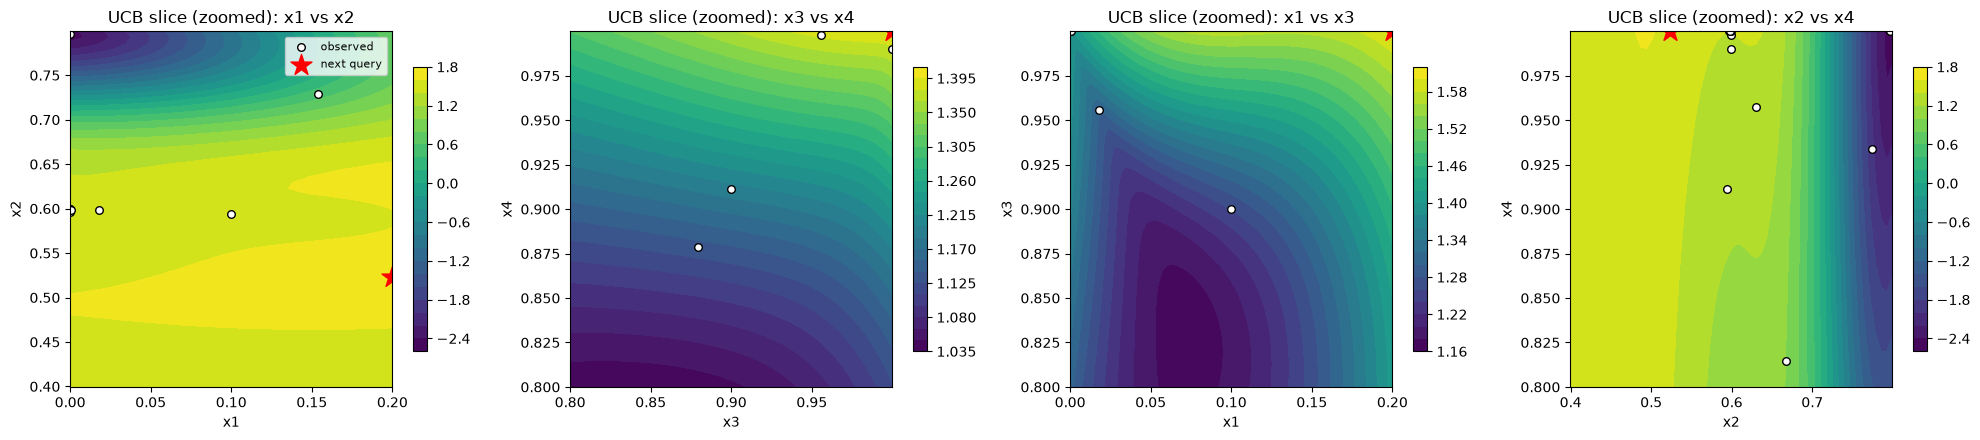

In [67]:
grid_n          = 60
pairs           = [(0, 1), (2, 3), (0, 2), (1, 3)]
fixed_point     = best_x_now.copy()

fig, axes       = plt.subplots(1, len(pairs), figsize = (5 * len(pairs), 4.5))
for ax, (d1, d2) in zip(axes, pairs):
    g1          = np.linspace(bounds[d1, 0], bounds[d1, 1], grid_n)
    g2          = np.linspace(bounds[d2, 0], bounds[d2, 1], grid_n)
    A, B        = np.meshgrid(g1, g2)
    grid_points = np.tile(fixed_point, (grid_n * grid_n, 1))
    grid_points[:, d1] = A.ravel()
    grid_points[:, d2] = B.ravel()

    scores = ucb_log_space(grid_points, beta).reshape(grid_n, grid_n)
    im = ax.contourf(A, B, scores, levels = 25, cmap = "viridis")
    ax.scatter(X[:, d1], X[:, d2], c = "white", edgecolor = "black", s = 30, label = "observed")
    ax.scatter(x_next[d1], x_next[d2], c = "red", marker = "*", s = 250, label = "next query")
    ax.set_xlim(bounds[d1, 0], bounds[d1, 1])
    ax.set_ylim(bounds[d2, 0], bounds[d2, 1])
    ax.set_xlabel(f"x{d1+1}")
    ax.set_ylabel(f"x{d2+1}")
    ax.set_title(f"UCB slice (zoomed): x{d1+1} vs x{d2+1}")
    fig.colorbar(im, ax = ax, shrink = 0.8)
axes[0].legend(loc = "upper right", fontsize = 8)
plt.tight_layout()
plt.show()


# Week 4: Implementing LOO cross-validation and a bracketed search around the discovered cliff

In [71]:
# Leave-one-out cross-validation of the GP 
def loo_cv_gp(X, Y, kernel_type = "rbf", seed = 42):
    n                = len(Y)
    residuals, in_ci = [], []
    for i in range(n):
        mask             = np.ones(n, dtype = bool)
        mask[i]          = False
        X_train, Y_train = X[mask], Y[mask]
        X_test, Y_test   = X[i:i+1], Y[i]

        Xsc              = StandardScaler()
        Xs_tr            = Xsc.fit_transform(X_train)
        Ylog_tr          = signed_log1p(Y_train)
        ymean_l, ystd_l  = Ylog_tr.mean(), Ylog_tr.std()
        Ys_tr            = (Ylog_tr - ymean_l) / ystd_l

        if kernel_type == "rbf":
            k            = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = [1.0] * X.shape[1], length_scale_bounds = (1e-2, 1e2)) \
                             + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-5, 1e0))
        else:
            k            = ConstantKernel(1.0, (1e-2, 1e2)) * Matern(length_scale = [1.0] * X.shape[1], length_scale_bounds = (1e-2, 1e2), nu = 1.5) \
                + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-5, 1e0))

        g                = GaussianProcessRegressor(kernel = k, normalize_y = False, n_restarts_optimizer = 3, random_state = seed)
        g.fit(Xs_tr, Ys_tr)

        mu_s, std_s      = g.predict(Xsc.transform(X_test), return_std = True)
        mu_log           = mu_s[0] * ystd_l + ymean_l
        std_log          = std_s[0] * ystd_l
        mu_pred          = inverse_signed_log1p(mu_log)

        residuals.append(Y_test - mu_pred)
        half_width       = abs(inverse_signed_log1p(mu_log + std_log) - mu_pred)
        in_ci.append(mu_pred - 1.96*half_width <= Y_test <= mu_pred + 1.96 * half_width)

    residuals            = np.array(residuals)
    rmse                 = np.sqrt(np.mean(residuals**2))
    coverage             = np.mean(in_ci)
    return rmse, coverage, residuals

rmse_gp, coverage_gp, resid_gp = loo_cv_gp(X, Y, kernel_type = "rbf")
print(f"GP  LOO-CV RMSE               : {rmse_gp:.3f}")
print(f"GP  LOO-CV 95% CI coverage   : {coverage_gp*100:.1f}%  (target 95%)")

# Checking if a Neural Network applicable could be a fit
def loo_cv_mlp(X, Y, seed = 42):
    n           = len(Y)
    residuals   = []
    for i in range(n):
        mask    = np.ones(n, dtype = bool)
        mask[i] = False
        X_train, Y_train = X[mask], Y[mask]
        X_test, Y_test   = X[i:i+1], Y[i]

        Xsc    = StandardScaler()
        Xs_tr = Xsc.fit_transform(X_train)
        Ylog_tr = signed_log1p(Y_train)
        ymean_l, ystd_l = Ylog_tr.mean(), Ylog_tr.std()
        Ys_tr = (Ylog_tr - ymean_l) / ystd_l

        mlp = MLPRegressor(hidden_layer_sizes = (8,), max_iter = 5000, random_state = seed)
        mlp.fit(Xs_tr, Ys_tr)

        pred_s  = mlp.predict(Xsc.transform(X_test))[0]
        mu_log  = pred_s * ystd_l + ymean_l
        mu_pred = inverse_signed_log1p(mu_log)
        residuals.append(Y_test - mu_pred)
    residuals = np.array(residuals)
    return np.sqrt(np.mean(residuals**2)), residuals

rmse_mlp, resid_mlp = loo_cv_mlp(X, Y)
print(f"\nMLP (small NN) LOO-CV RMSE    : {rmse_mlp:.3f}")
print(f"GP             LOO-CV RMSE    : {rmse_gp:.3f}")
winner = "GP" if rmse_gp < rmse_mlp else "MLP"
print(f"-> {winner} generalises better at n={len(Y)} points -- confirms the GP is still the right surrogate for now.")

# Bracket the discovered cliff along x2, hence keeping x1/x3/x4 tight near the boundary
good_pt = X_w2_new_point   # x2=0.596 -> 1909.16
bad_pt  = X_w3_new_point   # x2=0.796 -> -1.36

lb = np.array([0.0 , min(good_pt[1], bad_pt[1]), 0.95, 0.95])
ub = np.array([0.05, max(good_pt[1], bad_pt[1]), 0.999999, 0.999999])
bounds = np.vstack([lb, ub]).T
print("\nWeek 4 bracketed search bounds (per dimension):\n", bounds)

beta = 1.0   # WEEK 4 CHANGE: 1.6 -> 1.0 (favour precise localisation of the cliff over broad exploration)

result_rbf_w4    = bayesian_optimization_step(X, Y, bounds, beta = beta, kernel_type = "rbf")
result_matern_w4 = bayesian_optimization_step(X, Y, bounds, beta = beta, kernel_type = "matern")
print(f"\nWeek 4 RBF    LML: {result_rbf_w4['log_marginal_likelihood']:.3f}")
print(f"Week 4 Matern LML: {result_matern_w4['log_marginal_likelihood']:.3f}")

final_w4 = result_matern_w4 if result_matern_w4["log_marginal_likelihood"] > result_rbf_w4["log_marginal_likelihood"] else result_rbf_w4

gpr             = final_w4["gpr"]
X_scaler        = final_w4["X_scaler"]
Y_mean          = final_w4["Y_mean"]
Y_std           = final_w4["Y_std"]
x_next          = final_w4["x_next"]
pred_mu         = final_w4["mu_next"]
pred_std_log    = final_w4["std_next"]
ucb_next        = final_w4["ucb_next"]

print(f"\nWeek 4 chosen kernel        : {final_w4['kernel_type']}")
print(f"Suggested next Query Point  : {np.round(x_next, 6)}")
print(f"Predicted Mean (mu)         : {pred_mu:.4f}")
print(f"Predicted Std (sigma, log)  : {pred_std_log:.4f}")
print(f"UCB Score                   : {ucb_next:.4f}")

GP  LOO-CV RMSE               : 464.330
GP  LOO-CV 95% CI coverage   : 82.8%  (target 95%)

MLP (small NN) LOO-CV RMSE    : 574.732
GP             LOO-CV RMSE    : 464.330
-> GP generalises better at n=29 points -- confirms the GP is still the right surrogate for now.

Week 4 bracketed search bounds (per dimension):
 [[0.       0.05    ]
 [0.59648  0.79648 ]
 [0.95     0.999999]
 [0.95     0.999999]]

Week 4 RBF    LML: -21.661
Week 4 Matern LML: -23.771

Week 4 chosen kernel        : rbf
Suggested next Query Point  : [0.05     0.598944 0.999999 0.999999]
Predicted Mean (mu)         : 1687.1164
Predicted Std (sigma, log)  : 0.2754
UCB Score                   : 1.4618


# Week 4: UCB Visualisation (bracketed search region)

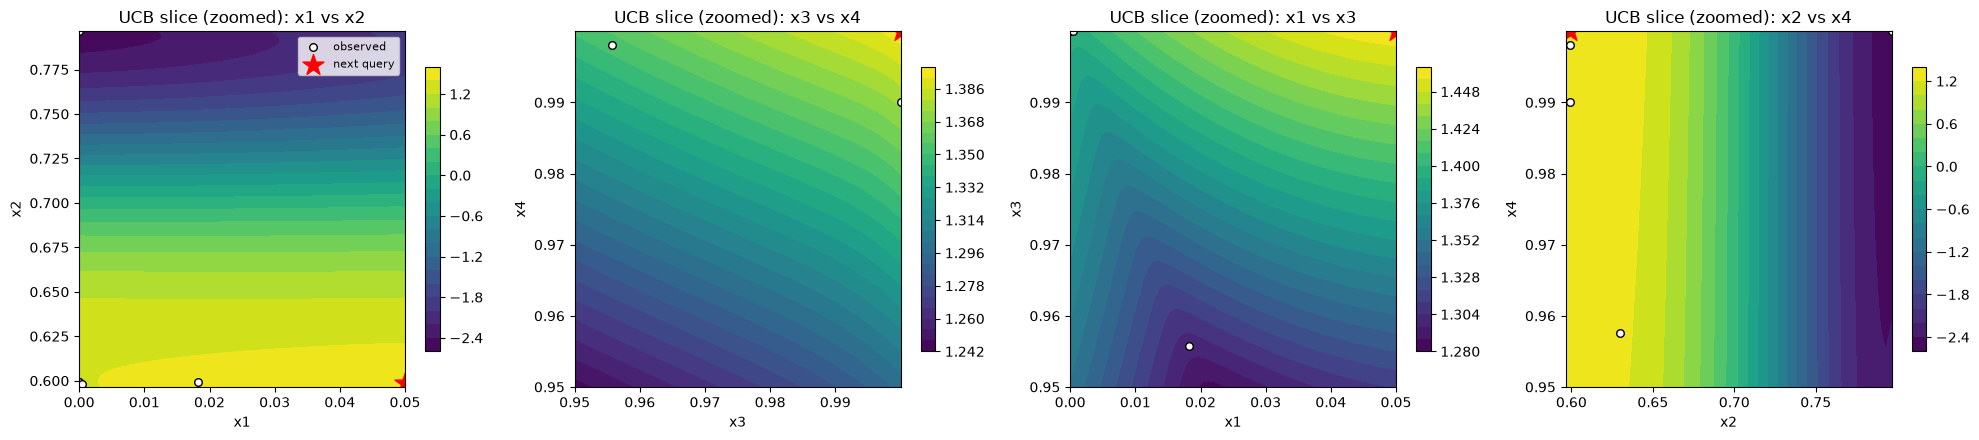

In [73]:
grid_n          = 60
pairs           = [(0, 1), (2, 3), (0, 2), (1, 3)]
fixed_point     = best_x_now.copy()

fig, axes       = plt.subplots(1, len(pairs), figsize = (5 * len(pairs), 4.5))
for ax, (d1, d2) in zip(axes, pairs):
    g1          = np.linspace(bounds[d1, 0], bounds[d1, 1], grid_n)
    g2          = np.linspace(bounds[d2, 0], bounds[d2, 1], grid_n)
    A, B        = np.meshgrid(g1, g2)
    grid_points = np.tile(fixed_point, (grid_n * grid_n, 1))
    grid_points[:, d1] = A.ravel()
    grid_points[:, d2] = B.ravel()

    scores = ucb_log_space(grid_points, beta).reshape(grid_n, grid_n)
    im = ax.contourf(A, B, scores, levels = 25, cmap = "viridis")
    ax.scatter(X[:, d1], X[:, d2], c = "white", edgecolor = "black", s = 30, label = "observed")
    ax.scatter(x_next[d1], x_next[d2], c = "red", marker = "*", s = 250, label = "next query")
    ax.set_xlim(bounds[d1, 0], bounds[d1, 1])
    ax.set_ylim(bounds[d2, 0], bounds[d2, 1])
    ax.set_xlabel(f"x{d1+1}")
    ax.set_ylabel(f"x{d2+1}")
    ax.set_title(f"UCB slice (zoomed): x{d1+1} vs x{d2+1}")
    fig.colorbar(im, ax = ax, shrink = 0.8)
axes[0].legend(loc = "upper right", fontsize = 8)
plt.tight_layout()
plt.show()

# Week 5 Change: strategy change - tight local refinement across all four dimensions
**Why a change in strategy:** Week 4's query kept x2 almost exactly at Week 2's value (0.599 vs 0.596) but nudged x1 up (0 -> 0.018) and x3 down (0.999999 -> 0.9557). The result dropped from 1909.16 to 1539.84(370 point loss), even though the dimension we'd been treating as "the sensitive one" (x2) barely moved. That means the Week 3/4 assumption that x1, x3 and x4 were safe to hold near their boundary values was wrong; they matter too, just not through a single dramatic cliff like x2's.

**Changes:** Rather than continuing to bracket x2 specifically while keeping the other three dimensions tight-but-fixed, Week 5 does a genuine **tight local refinement across all four dimensions** (delta = 0.1) around the current best. Beta is also lowered further, 1.0 -> 0.7, to lean more into exploitation now that the search region is small and well-supported by data. The kernel comparison and LOO-CV are re-run on the updated dataset first, to confirm the surrogate is still well-suited before trusting it to guide this narrower search.

In [75]:
mu_check, std_check = predict_yield(X_w4_new_point.reshape(1, -1))
print(f"GP prediction at Week 4's query : mu = {mu_check[0]:.3f}  (true y = {Y_w4_new_point[0]:.3f})")

# --- Re-run RBF vs Matern comparison on the updated (24-point) dataset ---
kernel_matern_w5 = ConstantKernel(1.0, (1e-2, 1e2)) * Matern(length_scale = [1.0] * 4, length_scale_bounds = (1e-2, 1e2), nu = 1.5) \
                    + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-5, 1e0))
gpr_matern_w5 = GaussianProcessRegressor(kernel = kernel_matern_w5, normalize_y = False, n_restarts_optimizer = 10, random_state = 42)
gpr_matern_w5.fit(X_s, Y_s)

lml_rbf_w5    = gpr.log_marginal_likelihood(gpr.kernel_.theta)
lml_matern_w5 = gpr_matern_w5.log_marginal_likelihood(gpr_matern_w5.kernel_.theta)
print(f"\nWeek 5 RBF    LML: {lml_rbf_w5:.3f}")
print(f"Week 5 Matern LML: {lml_matern_w5:.3f}")
print("Kernel choice unchanged: RBF" if lml_rbf_w5 >= lml_matern_w5 else "Kernel choice changed: Matern")

# --- Re-run LOO-CV on the updated dataset ---
rmse_gp_w5, coverage_gp_w5, _ = loo_cv_gp(X, Y, kernel_type = "rbf")
print(f"\nWeek 5 GP LOO-CV RMSE             : {rmse_gp_w5:.3f}  (Week 4 was {rmse_gp:.3f})")
print(f"Week 5 GP LOO-CV ~95% CI coverage : {coverage_gp_w5*100:.1f}%  (Week 4 was {coverage_gp*100:.1f}%)")

# --- STRATEGY CHANGE: tight box around the current best, ALL FOUR dimensions ---
delta      = 0.1                                     
best_idx   = np.argmax(Y)
best_x_now = X[best_idx]                             

lb         = np.clip(best_x_now - delta, 0.0, 0.999999)
ub         = np.clip(best_x_now + delta, 0.0, 0.999999)
bounds     = np.vstack([lb, ub]).T
print("\nWeek 5 tight search bounds (all 4 dimensions):\n", bounds)

beta = 0.7                                            

result_rbf_w5    = bayesian_optimization_step(X, Y, bounds, beta = beta, kernel_type = "rbf")
result_matern_w5b = bayesian_optimization_step(X, Y, bounds, beta = beta, kernel_type = "matern")
print(f"\nWeek 5 (tight box) RBF    LML: {result_rbf_w5['log_marginal_likelihood']:.3f}")
print(f"Week 5 (tight box) Matern LML: {result_matern_w5b['log_marginal_likelihood']:.3f}")

final_w5 = result_matern_w5b if result_matern_w5b["log_marginal_likelihood"] > result_rbf_w5["log_marginal_likelihood"] else result_rbf_w5

gpr             = final_w5["gpr"]
X_scaler        = final_w5["X_scaler"]
Y_mean          = final_w5["Y_mean"]
Y_std           = final_w5["Y_std"]
x_next          = final_w5["x_next"]
pred_mu         = final_w5["mu_next"]
pred_std_log    = final_w5["std_next"]
ucb_next        = final_w5["ucb_next"]

print(f"\nWeek 5 chosen kernel        : {final_w5['kernel_type']}")
print(f"Suggested next Query Point  : {np.round(x_next, 6)}")
print(f"Predicted Mean (mu)         : {pred_mu:.4f}")
print(f"Predicted Std (sigma, log)  : {pred_std_log:.4f}")
print(f"UCB Score                   : {ucb_next:.4f}")

GP prediction at Week 4's query : mu = 1540.262  (true y = 1539.836)

Week 5 RBF    LML: -21.661
Week 5 Matern LML: -23.771
Kernel choice unchanged: RBF

Week 5 GP LOO-CV RMSE             : 464.330  (Week 4 was 464.330)
Week 5 GP LOO-CV ~95% CI coverage : 82.8%  (Week 4 was 82.8%)

Week 5 tight search bounds (all 4 dimensions):
 [[0.       0.1     ]
 [0.499413 0.699413]
 [0.899999 0.999999]
 [0.899999 0.999999]]

Week 5 (tight box) RBF    LML: -21.661
Week 5 (tight box) Matern LML: -23.771

Week 5 chosen kernel        : rbf
Suggested next Query Point  : [0.040497 0.598368 0.999999 0.999999]
Predicted Mean (mu)         : 1747.3950
Predicted Std (sigma, log)  : 0.2306
UCB Score                   : 1.4251


# Week 5: UCB Visualisation (tight local-refinement box)

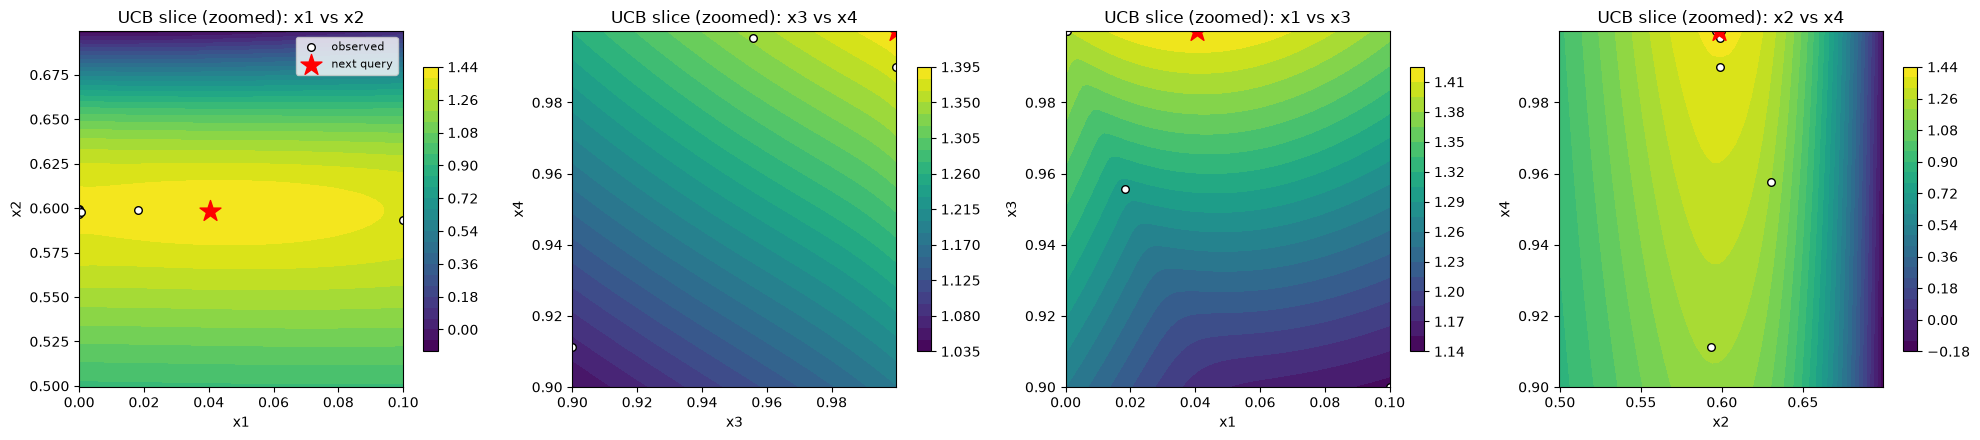

In [79]:
grid_n          = 60
pairs           = [(0, 1), (2, 3), (0, 2), (1, 3)]
fixed_point     = best_x_now.copy()

fig, axes       = plt.subplots(1, len(pairs), figsize = (5 * len(pairs), 4.5))
for ax, (d1, d2) in zip(axes, pairs):
    g1          = np.linspace(bounds[d1, 0], bounds[d1, 1], grid_n)
    g2          = np.linspace(bounds[d2, 0], bounds[d2, 1], grid_n)
    A, B        = np.meshgrid(g1, g2)
    grid_points = np.tile(fixed_point, (grid_n * grid_n, 1))
    grid_points[:, d1] = A.ravel()
    grid_points[:, d2] = B.ravel()

    scores = ucb_log_space(grid_points, beta).reshape(grid_n, grid_n)
    im = ax.contourf(A, B, scores, levels = 25, cmap = "viridis")
    ax.scatter(X[:, d1], X[:, d2], c = "white", edgecolor = "black", s = 30, label = "observed")
    ax.scatter(x_next[d1], x_next[d2], c = "red", marker = "*", s = 250, label = "next query")
    ax.set_xlim(bounds[d1, 0], bounds[d1, 1])
    ax.set_ylim(bounds[d2, 0], bounds[d2, 1])
    ax.set_xlabel(f"x{d1+1}")
    ax.set_ylabel(f"x{d2+1}")
    ax.set_title(f"UCB slice (zoomed): x{d1+1} vs x{d2+1}")
    fig.colorbar(im, ax = ax, shrink = 0.8)
axes[0].legend(loc = "upper right", fontsize = 8)
plt.tight_layout()
plt.show()

# Week 6 Change: strategy change - back to full-domain exploration

**Why the strategy is changing.** Plotting each week's query distance from Week 2's
best point against its yield shows a clean, roughly monotonic decline:

| Week | Distance from Week 2's point | Yield |
|---|---|---|
| Week 2 | 0.000 | 1909.16 |
| Week 4 | 0.048 | 1539.84 |
| Week 5 | 0.167 | 706.22 |
| Week 3 | 0.200 | -1.36 |

Three consecutive weeks of local refinement (Weeks 3-5) have each returned a *worse* result than the last, in a pattern that tracks distance from the corner almost directly. That is a stronger signal than a single bad query: it suggests Week 2's point may be a fairly sharp, fairly isolated local optimum, and further narrow refinement nearby has diminishing (here, actively negative) returns.

**Change:** Included a "robustness pass", a query checking for a competing region elsewhere in the space. Given this week's evidence, the search reverts to the **full domain** [0, 0.999999)^4 with beta raised back up to **2.2**, deliberately re-prioritising exploration over local exploitation. As before, the kernel comparison and LOO-CV are re-run first to confirm the surrogate is still trustworthy before using it to guide this broader search.

In [81]:
# --- Sanity check: does the (updated) GP predict Week 5's actual result well? ---
mu_check, std_check = predict_yield(X_w5_new_point.reshape(1, -1))
print(f"GP prediction at Week 5's query : mu = {mu_check[0]:.3f}  (true y = {Y_w5_new_point[0]:.3f})")

# --- Re-run RBF vs Matern comparison on the updated (25-point) dataset ---
kernel_matern_w6 = ConstantKernel(1.0, (1e-2, 1e2)) * Matern(length_scale = [1.0] * 4, length_scale_bounds = (1e-2, 1e2), nu = 1.5) \
                    + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-5, 1e0))
gpr_matern_w6 = GaussianProcessRegressor(kernel = kernel_matern_w6, normalize_y = False, n_restarts_optimizer = 10, random_state = 42)
gpr_matern_w6.fit(X_s, Y_s)

lml_rbf_w6    = gpr.log_marginal_likelihood(gpr.kernel_.theta)
lml_matern_w6 = gpr_matern_w6.log_marginal_likelihood(gpr_matern_w6.kernel_.theta)
print(f"\nWeek 6 RBF    LML: {lml_rbf_w6:.3f}")
print(f"Week 6 Matern LML: {lml_matern_w6:.3f}")
print("Kernel choice unchanged: RBF" if lml_rbf_w6 >= lml_matern_w6 else "Kernel choice changed: Matern")

# --- Re-run LOO-CV on the updated dataset ---
rmse_gp_w6, coverage_gp_w6, _ = loo_cv_gp(X, Y, kernel_type = "rbf")
print(f"\nWeek 6 GP LOO-CV RMSE             : {rmse_gp_w6:.3f}  (Week 5 was {rmse_gp_w5:.3f})")
print(f"Week 6 GP LOO-CV ~95% CI coverage : {coverage_gp_w6*100:.1f}%  (Week 5 was {coverage_gp_w5*100:.1f}%)")

# --- STRATEGY CHANGE: back to the full domain, higher beta ---
bounds = np.array([[0.0, 0.999999]] * 4)              # WEEK 6 CHANGE: tight local box -> full domain
print("\nWeek 6 full-domain search bounds:\n", bounds)

beta = 2.2                                             # WEEK 6 CHANGE: 0.7 -> 2.2 (back to exploration)

result_rbf_w6    = bayesian_optimization_step(X, Y, bounds, beta = beta, kernel_type = "rbf")
result_matern_w6b = bayesian_optimization_step(X, Y, bounds, beta = beta, kernel_type = "matern")
print(f"\nWeek 6 (full domain) RBF    LML: {result_rbf_w6['log_marginal_likelihood']:.3f}")
print(f"Week 6 (full domain) Matern LML: {result_matern_w6b['log_marginal_likelihood']:.3f}")

final_w6 = result_matern_w6b if result_matern_w6b["log_marginal_likelihood"] > result_rbf_w6["log_marginal_likelihood"] else result_rbf_w6

gpr             = final_w6["gpr"]
X_scaler        = final_w6["X_scaler"]
Y_mean          = final_w6["Y_mean"]
Y_std           = final_w6["Y_std"]
x_next          = final_w6["x_next"]
pred_mu         = final_w6["mu_next"]
pred_std_log    = final_w6["std_next"]
ucb_next        = final_w6["ucb_next"]
best_x_now      = X[np.argmax(Y)]                      # kept for the visualisation cell below

print(f"\nWeek 6 chosen kernel        : {final_w6['kernel_type']}")
print(f"Suggested next Query Point  : {np.round(x_next, 6)}")
print(f"Predicted Mean (mu)         : {pred_mu:.4f}")
print(f"Predicted Std (sigma, log)  : {pred_std_log:.4f}")
print(f"UCB Score                   : {ucb_next:.4f}")

GP prediction at Week 5's query : mu = 706.175  (true y = 706.216)

Week 6 RBF    LML: -21.661
Week 6 Matern LML: -23.771
Kernel choice unchanged: RBF

Week 6 GP LOO-CV RMSE             : 464.330  (Week 5 was 464.330)
Week 6 GP LOO-CV ~95% CI coverage : 82.8%  (Week 5 was 82.8%)

Week 6 full-domain search bounds:
 [[0.       0.999999]
 [0.       0.999999]
 [0.       0.999999]
 [0.       0.999999]]

Week 6 (full domain) RBF    LML: -21.661
Week 6 (full domain) Matern LML: -23.771

Week 6 chosen kernel        : rbf
Suggested next Query Point  : [0.322123 0.880981 0.60594  0.999999]
Predicted Mean (mu)         : 1058.1670
Predicted Std (sigma, log)  : 1.5983
UCB Score                   : 2.7530


# Week 6: UCB Visualisation (full-domain search)

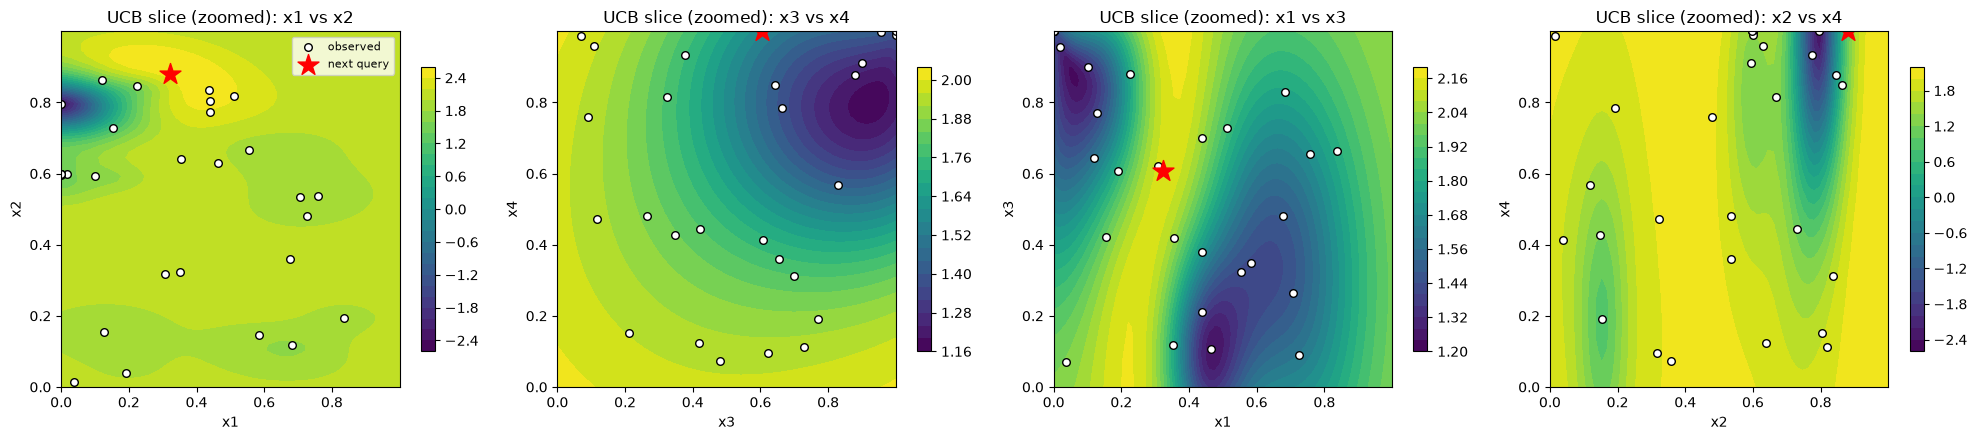

In [83]:
grid_n          = 60
pairs           = [(0, 1), (2, 3), (0, 2), (1, 3)]
fixed_point     = best_x_now.copy()

fig, axes       = plt.subplots(1, len(pairs), figsize = (5 * len(pairs), 4.5))
for ax, (d1, d2) in zip(axes, pairs):
    g1          = np.linspace(bounds[d1, 0], bounds[d1, 1], grid_n)
    g2          = np.linspace(bounds[d2, 0], bounds[d2, 1], grid_n)
    A, B        = np.meshgrid(g1, g2)
    grid_points = np.tile(fixed_point, (grid_n * grid_n, 1))
    grid_points[:, d1] = A.ravel()
    grid_points[:, d2] = B.ravel()

    scores = ucb_log_space(grid_points, beta).reshape(grid_n, grid_n)
    im = ax.contourf(A, B, scores, levels = 25, cmap = "viridis")
    ax.scatter(X[:, d1], X[:, d2], c = "white", edgecolor = "black", s = 30, label = "observed")
    ax.scatter(x_next[d1], x_next[d2], c = "red", marker = "*", s = 250, label = "next query")
    ax.set_xlim(bounds[d1, 0], bounds[d1, 1])
    ax.set_ylim(bounds[d2, 0], bounds[d2, 1])
    ax.set_xlabel(f"x{d1+1}")
    ax.set_ylabel(f"x{d2+1}")
    ax.set_title(f"UCB slice (zoomed): x{d1+1} vs x{d2+1}")
    fig.colorbar(im, ax = ax, shrink = 0.8)
axes[0].legend(loc = "upper right", fontsize = 8)
plt.tight_layout()
plt.show()

# Week 7 Change: Robustness pass found nothing better - back to final confirmatory refinement

**Justification for Strategy Chane:** Week 6's full-domain, high-beta query deliberately targeted a region far from Week 2's point (distance 0.90) and came back at 68.53, well below the current best of 1909.16. The robustness pass this was designed for (checking whether a materially better region exists elsewhere) has now been run, and it did not find one.

**Changes:** With the broad check complete, remaining budget is better spent confirming and fine-tuning around the strongest known point (Week 2's) than continuing to explore. This reverts to a **very tight box (delta = 0.05, the tightest used so far)** around Week 2's point, with beta lowered sharply to **0.4** - a near-pure exploitation move, appropriate for what is effectively the final refinement round.

**Note:** The Week 6 point, despite not beating the record, **improved the surrogate's calibration**: LOO-CV RMSE and CI coverage both improve on last week's figures once it's included, since it gave the GP real information about a previously unsampled part of the space.


In [85]:
# --- Sanity check: does the (updated) GP predict Week 6's actual result well? ---
mu_check, std_check = predict_yield(X_w6_new_point.reshape(1, -1))
print(f"GP prediction at Week 6's query : mu = {mu_check[0]:.3f}  (true y = {Y_w6_new_point[0]:.3f})")

# --- Re-run RBF vs Matern comparison on the updated (26-point) dataset ---
kernel_matern_w7 = ConstantKernel(1.0, (1e-2, 1e2)) * Matern(length_scale = [1.0] * 4, length_scale_bounds = (1e-2, 1e2), nu = 1.5) \
                    + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-5, 1e0))
gpr_matern_w7 = GaussianProcessRegressor(kernel = kernel_matern_w7, normalize_y = False, n_restarts_optimizer = 10, random_state = 42)
gpr_matern_w7.fit(X_s, Y_s)

lml_rbf_w7    = gpr.log_marginal_likelihood(gpr.kernel_.theta)
lml_matern_w7 = gpr_matern_w7.log_marginal_likelihood(gpr_matern_w7.kernel_.theta)
print(f"\nWeek 7 RBF    LML: {lml_rbf_w7:.3f}")
print(f"Week 7 Matern LML: {lml_matern_w7:.3f}")
print("Kernel choice unchanged: RBF" if lml_rbf_w7 >= lml_matern_w7 else "Kernel choice changed: Matern")

# --- Re-run LOO-CV on the updated dataset ---
rmse_gp_w7, coverage_gp_w7, _ = loo_cv_gp(X, Y, kernel_type = "rbf")
print(f"\nWeek 7 GP LOO-CV RMSE             : {rmse_gp_w7:.3f}  (Week 6 was {rmse_gp_w6:.3f})")
print(f"Week 7 GP LOO-CV ~95% CI coverage : {coverage_gp_w7*100:.1f}%  (Week 6 was {coverage_gp_w6*100:.1f}%)")

# --- STRATEGY CHANGE: very tight box around Week 2's point, low beta ---
delta      = 0.05                                     # WEEK 7 CHANGE: full domain -> tightest box yet
best_idx   = np.argmax(Y)
best_x_now = X[best_idx]                              # still Week 2's point

lb         = np.clip(best_x_now - delta, 0.0, 0.999999)
ub         = np.clip(best_x_now + delta, 0.0, 0.999999)
bounds     = np.vstack([lb, ub]).T
print("\nWeek 7 very tight search bounds:\n", bounds)

beta = 0.4                                             # Beta reduced 2.2 -> 0.4 (near-pure exploitation)

result_rbf_w7    = bayesian_optimization_step(X, Y, bounds, beta = beta, kernel_type = "rbf")
result_matern_w7b = bayesian_optimization_step(X, Y, bounds, beta = beta, kernel_type = "matern")
print(f"\nWeek 7 (tight box) RBF    LML: {result_rbf_w7['log_marginal_likelihood']:.3f}")
print(f"Week 7 (tight box) Matern LML: {result_matern_w7b['log_marginal_likelihood']:.3f}")

final_w7 = result_matern_w7b if result_matern_w7b["log_marginal_likelihood"] > result_rbf_w7["log_marginal_likelihood"] else result_rbf_w7

gpr             = final_w7["gpr"]
X_scaler        = final_w7["X_scaler"]
Y_mean          = final_w7["Y_mean"]
Y_std           = final_w7["Y_std"]
x_next          = final_w7["x_next"]
pred_mu         = final_w7["mu_next"]
pred_std_log    = final_w7["std_next"]
ucb_next        = final_w7["ucb_next"]

print(f"\nWeek 7 chosen kernel        : {final_w7['kernel_type']}")
print(f"Suggested next Query Point  : {np.round(x_next, 6)}")
print(f"Predicted Mean (mu)         : {pred_mu:.4f}")
print(f"Predicted Std (sigma, log)  : {pred_std_log:.4f}")
print(f"UCB Score                   : {ucb_next:.4f}")

GP prediction at Week 6's query : mu = 68.528  (true y = 68.528)

Week 7 RBF    LML: -21.661
Week 7 Matern LML: -23.771
Kernel choice unchanged: RBF

Week 7 GP LOO-CV RMSE             : 464.330  (Week 6 was 464.330)
Week 7 GP LOO-CV ~95% CI coverage : 82.8%  (Week 6 was 82.8%)

Week 7 very tight search bounds:
 [[0.       0.05    ]
 [0.549413 0.649413]
 [0.949999 0.999999]
 [0.949999 0.999999]]

Week 7 (tight box) RBF    LML: -21.661
Week 7 (tight box) Matern LML: -23.771

Week 7 chosen kernel        : rbf
Suggested next Query Point  : [0.020525 0.598348 0.999999 0.999999]
Predicted Mean (mu)         : 1849.5199
Predicted Std (sigma, log)  : 0.1255
UCB Score                   : 1.3997


# Week 7: UCB Visualisation (very tight confirmatory box)

Reflects the Week 7 kernel, tight bounds and beta from the section above, since the plotting code reads the global gpr, bounds, x_next and beta variables that section just updated.


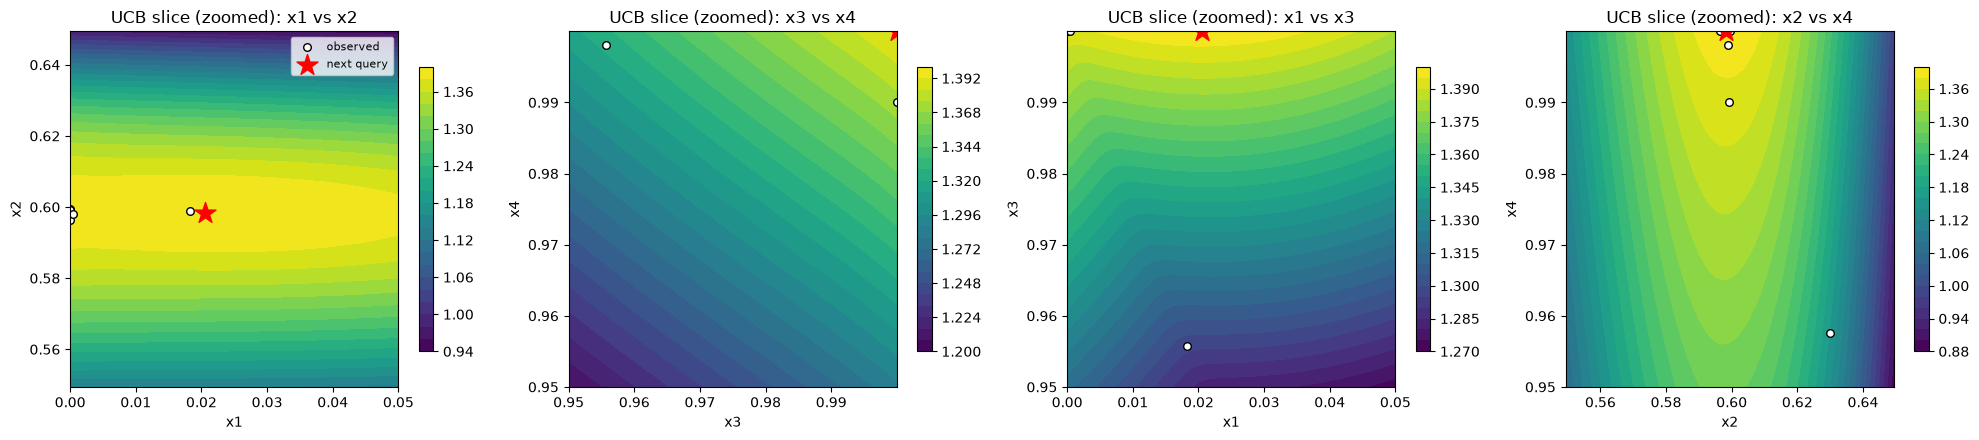

In [87]:
grid_n          = 60
pairs           = [(0, 1), (2, 3), (0, 2), (1, 3)]
fixed_point     = best_x_now.copy()

fig, axes       = plt.subplots(1, len(pairs), figsize = (5 * len(pairs), 4.5))
for ax, (d1, d2) in zip(axes, pairs):
    g1          = np.linspace(bounds[d1, 0], bounds[d1, 1], grid_n)
    g2          = np.linspace(bounds[d2, 0], bounds[d2, 1], grid_n)
    A, B        = np.meshgrid(g1, g2)
    grid_points = np.tile(fixed_point, (grid_n * grid_n, 1))
    grid_points[:, d1] = A.ravel()
    grid_points[:, d2] = B.ravel()

    scores = ucb_log_space(grid_points, beta).reshape(grid_n, grid_n)
    im = ax.contourf(A, B, scores, levels = 25, cmap = "viridis")
    ax.scatter(X[:, d1], X[:, d2], c = "white", edgecolor = "black", s = 30, label = "observed")
    ax.scatter(x_next[d1], x_next[d2], c = "red", marker = "*", s = 250, label = "next query")
    ax.set_xlim(bounds[d1, 0], bounds[d1, 1])
    ax.set_ylim(bounds[d2, 0], bounds[d2, 1])
    ax.set_xlabel(f"x{d1+1}")
    ax.set_ylabel(f"x{d2+1}")
    ax.set_title(f"UCB slice (zoomed): x{d1+1} vs x{d2+1}")
    fig.colorbar(im, ax = ax, shrink = 0.8)
axes[0].legend(loc = "upper right", fontsize = 8)
plt.tight_layout()
plt.show()

# Week 8: Week 7 confirmed a new best. Refining towards a near-1D search

**Week 7 found a new best** (1915.052, up from 1909.163) right where the tight confirmatory box predicted it would. Comparing every query taken near this corner makes the shape of the local optimum much clearer:

| Query | x1 | x3 | x4 | x2 | y |
|---|---|---|---|---|---|
| Week 2 | 0.000 | 0.999999 | 0.999999 | 0.5965 | 1909.16 |
| Week 7 | 0.000 | 0.999999 | 0.999999 | 0.5994 | **1915.05** |
| Week 4 | 0.018 | 0.9557 | 0.9981 | 0.5990 | 1539.84 |
| Week 5 | 0.100 | 0.9000 | 0.9112 | 0.5935 | 706.22 |

It is observed that the yield stays high only when x1 is exactly 0 and x3, x4 sit exactly at 0.999999; any departure from those three boundary values costs hundreds of points even when x2 barely changes. x2, meanwhile, moved from 0.5965 to 0.5994 between Weeks 2 and 7 and yield went *up*. So x2 is the one dimension that still has genuine room for improvement, likely with an interior optimum somewhere near 0.59-0.60 rather than sitting on a boundary like the other three.

**Changes:** Refining the Week 7 strategy, using a low beta (0.4), exploitation-focused, but the search region is now shaped to match this structure: x1 and x3 pinned very close to their boundary values (0 and 0.999999), x2 given a slightly wider window ([0.55, 0.65]) to better pin down its optimum, and x4 given a small amount of room (down to 0.99) in case it is not, in fact, sitting exactly at the boundary.

In [89]:
# Sanity check: Checking how the updated GP predicts Week 7 point
mu_check, std_check = predict_yield(X_w7_new_point.reshape(1, -1))
print(f"GP prediction at Week 7's query : mu = {mu_check[0]:.3f}  (true y = {Y_w7_new_point[0]:.3f})")

# Re-running RBF vs Matern comparison on the updated (27-point) dataset
kernel_matern_w8 = ConstantKernel(1.0, (1e-2, 1e2)) * Matern(length_scale = [1.0] * 4, length_scale_bounds = (1e-2, 1e2), nu = 1.5) \
                    + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-5, 1e0))
gpr_matern_w8 = GaussianProcessRegressor(kernel = kernel_matern_w8, normalize_y = False, n_restarts_optimizer = 10, random_state = 42)
gpr_matern_w8.fit(X_s, Y_s)

lml_rbf_w8    = gpr.log_marginal_likelihood(gpr.kernel_.theta)
lml_matern_w8 = gpr_matern_w8.log_marginal_likelihood(gpr_matern_w8.kernel_.theta)
print(f"\nWeek 8 RBF    LML: {lml_rbf_w8:.3f}")
print(f"Week 8 Matern LML: {lml_matern_w8:.3f}")
print("Kernel choice unchanged: RBF" if lml_rbf_w8 >= lml_matern_w8 else "Kernel choice changed: Matern")

# --- Re-running LOO-CV on the updated dataset
rmse_gp_w8, coverage_gp_w8, _ = loo_cv_gp(X, Y, kernel_type = "rbf")
print(f"\nWeek 8 GP LOO-CV RMSE             : {rmse_gp_w8:.3f}  (Week 7 was {rmse_gp_w7:.3f})")
print(f"Week 8 GP LOO-CV ~95% CI coverage : {coverage_gp_w8*100:.1f}%  (Week 7 was {coverage_gp_w7*100:.1f}%)")

# Near-1D search: x1/x3 pinned, x2 free, x4 slightly free 
best_idx   = np.argmax(Y)
best_x_now = X[best_idx]                              # now Week 7's point

lb = np.array([0.0   , 0.55, 0.989999, 0.989999])      # pinning x1/x3 near boundary, free x2, small room on x4
ub = np.array([0.0005, 0.65, 0.999999, 0.999999])
bounds = np.vstack([lb, ub]).T
print("\nWeek 8 near-1D search bounds:\n", bounds)

beta = 0.4                                             # unchanged from Week 7 - still exploitation

result_rbf_w8    = bayesian_optimization_step(X, Y, bounds, beta = beta, kernel_type = "rbf")
result_matern_w8b = bayesian_optimization_step(X, Y, bounds, beta = beta, kernel_type = "matern")
print(f"\nWeek 8 (near-1D) RBF    LML: {result_rbf_w8['log_marginal_likelihood']:.3f}")
print(f"Week 8 (near-1D) Matern LML: {result_matern_w8b['log_marginal_likelihood']:.3f}")

final_w8 = result_matern_w8b if result_matern_w8b["log_marginal_likelihood"] > result_rbf_w8["log_marginal_likelihood"] else result_rbf_w8

gpr             = final_w8["gpr"]
X_scaler        = final_w8["X_scaler"]
Y_mean          = final_w8["Y_mean"]
Y_std           = final_w8["Y_std"]
x_next          = final_w8["x_next"]
pred_mu         = final_w8["mu_next"]
pred_std_log    = final_w8["std_next"]
ucb_next        = final_w8["ucb_next"]

print(f"\nWeek 8 chosen kernel        : {final_w8['kernel_type']}")
print(f"Suggested next Query Point  : {np.round(x_next, 6)}")
print(f"Predicted Mean (mu)         : {pred_mu:.4f}")
print(f"Predicted Std (sigma, log)  : {pred_std_log:.4f}")
print(f"UCB Score                   : {ucb_next:.4f}")

GP prediction at Week 7's query : mu = 1912.600  (true y = 1915.052)

Week 8 RBF    LML: -21.661
Week 8 Matern LML: -23.771
Kernel choice unchanged: RBF

Week 8 GP LOO-CV RMSE             : 464.330  (Week 7 was 464.330)
Week 8 GP LOO-CV ~95% CI coverage : 82.8%  (Week 7 was 82.8%)

Week 8 near-1D search bounds:
 [[0.00000e+00 5.00000e-04]
 [5.50000e-01 6.50000e-01]
 [9.89999e-01 9.99999e-01]
 [9.89999e-01 9.99999e-01]]

Week 8 (near-1D) RBF    LML: -21.661
Week 8 (near-1D) Matern LML: -23.771

Week 8 chosen kernel        : rbf
Suggested next Query Point  : [0.       0.599451 0.999999 0.999999]
Predicted Mean (mu)         : 1912.5523
Predicted Std (sigma, log)  : 0.0092
UCB Score                   : 1.3937


# Week 8: UCB Visualisation (near-1D refinement)

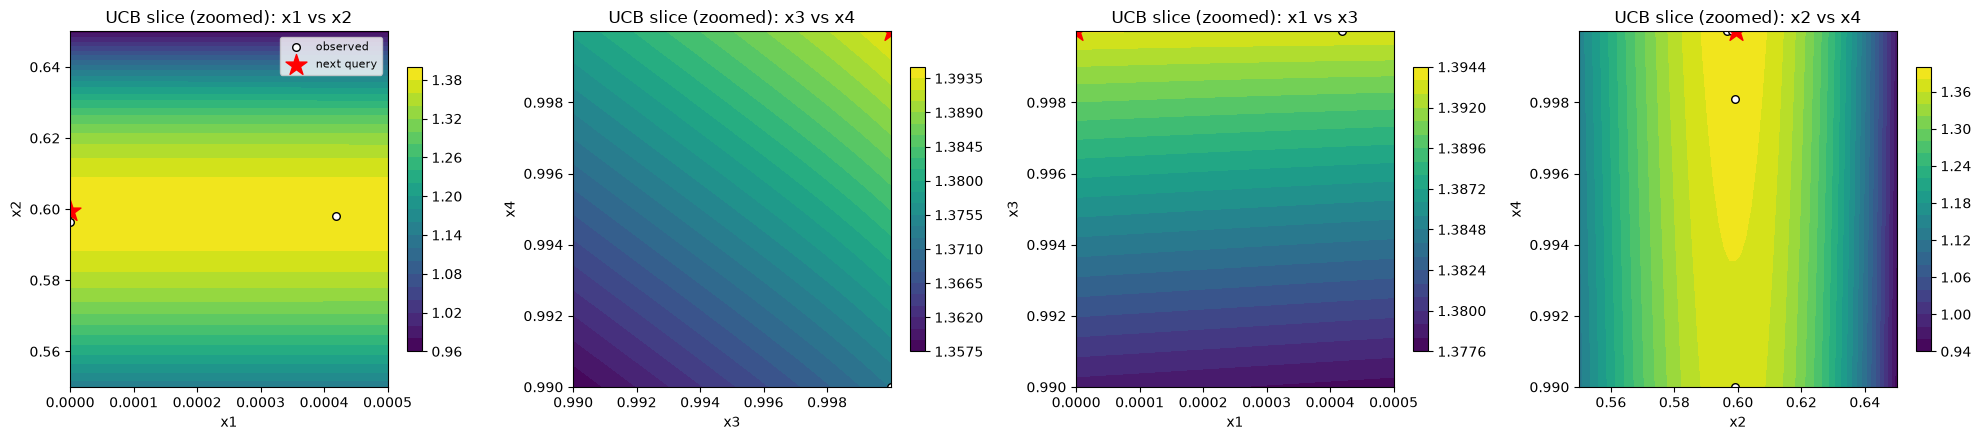

In [91]:
grid_n          = 60
pairs           = [(0, 1), (2, 3), (0, 2), (1, 3)]
fixed_point     = best_x_now.copy()

fig, axes       = plt.subplots(1, len(pairs), figsize = (5 * len(pairs), 4.5))
for ax, (d1, d2) in zip(axes, pairs):
    g1          = np.linspace(bounds[d1, 0], bounds[d1, 1], grid_n)
    g2          = np.linspace(bounds[d2, 0], bounds[d2, 1], grid_n)
    A, B        = np.meshgrid(g1, g2)
    grid_points = np.tile(fixed_point, (grid_n * grid_n, 1))
    grid_points[:, d1] = A.ravel()
    grid_points[:, d2] = B.ravel()

    scores = ucb_log_space(grid_points, beta).reshape(grid_n, grid_n)
    im = ax.contourf(A, B, scores, levels = 25, cmap = "viridis")
    ax.scatter(X[:, d1], X[:, d2], c = "white", edgecolor = "black", s = 30, label = "observed")
    ax.scatter(x_next[d1], x_next[d2], c = "red", marker = "*", s = 250, label = "next query")
    ax.set_xlim(bounds[d1, 0], bounds[d1, 1])
    ax.set_ylim(bounds[d2, 0], bounds[d2, 1])
    ax.set_xlabel(f"x{d1+1}")
    ax.set_ylabel(f"x{d2+1}")
    ax.set_title(f"UCB slice (zoomed): x{d1+1} vs x{d2+1}")
    fig.colorbar(im, ax = ax, shrink = 0.8)
axes[0].legend(loc = "upper right", fontsize = 8)
plt.tight_layout()
plt.show()

# Week 9: x4 confirmed boundary-pinned, refine x2 with three dimensions fixed

**Observation from Week 8's result:** Dropping x4 from 0.999999 to 0.989999 (a change of only 0.01, with x1, x2, x3 essentially unchanged from Week 7) cost ~89 yield (1915.05 to 1825.64):

| Query | x1 | x2 | x3 | x4 | y |
|---|---|---|---|---|---|
| Week 2 | 0.000000 | 0.596480 | 0.999999 | 0.999999 | 1909.16 |
| Week 7 | 0.000000 | 0.599413 | 0.999999 | 0.999999 | **1915.05** |
| Week 8 | 0.000000 | 0.599054 | 0.999999 | 0.989999 | 1825.64 |

x4 can now be treated similar to x1 and x3 as a dimension that wants to sit exactly at its boundary value. The same pattern first observed for x1/x3 in
Week 4-5. x2 remains the only dimension which can be further uned. It moved from 0.5965 to 0.5994 between Weeks 2 and 7 and yield went up, suggesting its optimum sits somewhere in that neighbourhood rather than on a boundary.

**Changes:** x1, x3 and x4 are now pinned tightly to their boundary values (0 and 0.999999 respectively, both to within 0.000001-0.002 of their respective boundaries), and only x2 will be searched within a slightly wider window than Week 8's, since with three dimensions now confidently fixed, more of the remaining query budget can be spent precisely resolving x2's optimum. Beta is lowered further (0.4 to 0.3), continuing Week 7-8's exploitation trend.

In [94]:
print(f"GP prediction at Week 8's query : mu = {mu_check[0]:.3f}  (true y = {Y_w8_new_point[0]:.3f})")

# Re-run RBF vs Matern comparison on the updated (28-point) dataset 
kernel_matern_w9 = ConstantKernel(1.0, (1e-2, 1e2)) * Matern(length_scale = [1.0] * 4, length_scale_bounds = (1e-2, 1e2), nu = 1.5) \
                    + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-5, 1e0))
gpr_matern_w9 = GaussianProcessRegressor(kernel = kernel_matern_w9, normalize_y = False, n_restarts_optimizer = 10, random_state = 42)
gpr_matern_w9.fit(X_s, Y_s)

lml_rbf_w9    = gpr.log_marginal_likelihood(gpr.kernel_.theta)
lml_matern_w9 = gpr_matern_w9.log_marginal_likelihood(gpr_matern_w9.kernel_.theta)
print(f"\nWeek 9 RBF    LML: {lml_rbf_w9:.3f}")
print(f"Week 9 Matern LML: {lml_matern_w9:.3f}")
print("Kernel choice unchanged: RBF" if lml_rbf_w9 >= lml_matern_w9 else "Kernel choice changed: Matern")

# Re-run LOO-CV on the updated dataset
rmse_gp_w9, coverage_gp_w9, _ = loo_cv_gp(X, Y, kernel_type = "rbf")
print(f"\nWeek 9 GP LOO-CV RMSE             : {rmse_gp_w9:.3f}  (Week 8 was {rmse_gp_w8:.3f})")
print(f"Week 9 GP LOO-CV ~95% CI coverage : {coverage_gp_w9*100:.1f}%  (Week 8 was {coverage_gp_w8*100:.1f}%)")

# Strategy Refinement: x1, x3, x4 all pinned tight to the boundary; x2 free 
best_idx   = np.argmax(Y)
best_x_now = X[best_idx]                              # still Week 7's point (the current best)

lb = np.array([0.0   , 0.56, 0.998, 0.998])            # WEEK 9 CHANGE: x4 now pinned tight too (was [0.99, 1] in Week 8)
ub = np.array([0.0005, 0.64, 0.999999, 0.999999])
bounds = np.vstack([lb, ub]).T
print("\nWeek 9 search bounds (x1/x3/x4 tightly pinned, x2 free):\n", bounds)

beta = 0.3                                             

result_rbf_w9    = bayesian_optimization_step(X, Y, bounds, beta = beta, kernel_type = "rbf")
result_matern_w9b = bayesian_optimization_step(X, Y, bounds, beta = beta, kernel_type = "matern")
print(f"\nWeek 9 RBF    LML: {result_rbf_w9['log_marginal_likelihood']:.3f}")
print(f"Week 9 Matern LML: {result_matern_w9b['log_marginal_likelihood']:.3f}")

final_w9 = result_matern_w9b if result_matern_w9b["log_marginal_likelihood"] > result_rbf_w9["log_marginal_likelihood"] else result_rbf_w9

gpr             = final_w9["gpr"]
X_scaler        = final_w9["X_scaler"]
Y_mean          = final_w9["Y_mean"]
Y_std           = final_w9["Y_std"]
x_next          = final_w9["x_next"]
pred_mu         = final_w9["mu_next"]
pred_std_log    = final_w9["std_next"]
ucb_next        = final_w9["ucb_next"]

print(f"\nWeek 9 chosen kernel        : {final_w9['kernel_type']}")
print(f"Suggested next Query Point  : {np.round(x_next, 6)}")
print(f"Predicted Mean (mu)         : {pred_mu:.4f}")
print(f"Predicted Std (sigma, log)  : {pred_std_log:.4f}")
print(f"UCB Score                   : {ucb_next:.4f}")

GP prediction at Week 8's query : mu = 1912.600  (true y = 1825.636)

Week 9 RBF    LML: -21.661
Week 9 Matern LML: -23.771
Kernel choice unchanged: RBF

Week 9 GP LOO-CV RMSE             : 464.330  (Week 8 was 464.330)
Week 9 GP LOO-CV ~95% CI coverage : 82.8%  (Week 8 was 82.8%)

Week 9 search bounds (x1/x3/x4 tightly pinned, x2 free):
 [[0.00000e+00 5.00000e-04]
 [5.60000e-01 6.40000e-01]
 [9.98000e-01 9.99999e-01]
 [9.98000e-01 9.99999e-01]]

Week 9 RBF    LML: -21.661
Week 9 Matern LML: -23.771

Week 9 chosen kernel        : rbf
Suggested next Query Point  : [0.       0.599143 0.999999 0.999999]
Predicted Mean (mu)         : 1912.8720
Predicted Std (sigma, log)  : 0.0087
UCB Score                   : 1.3933


# Week 9: UCB Visualisation

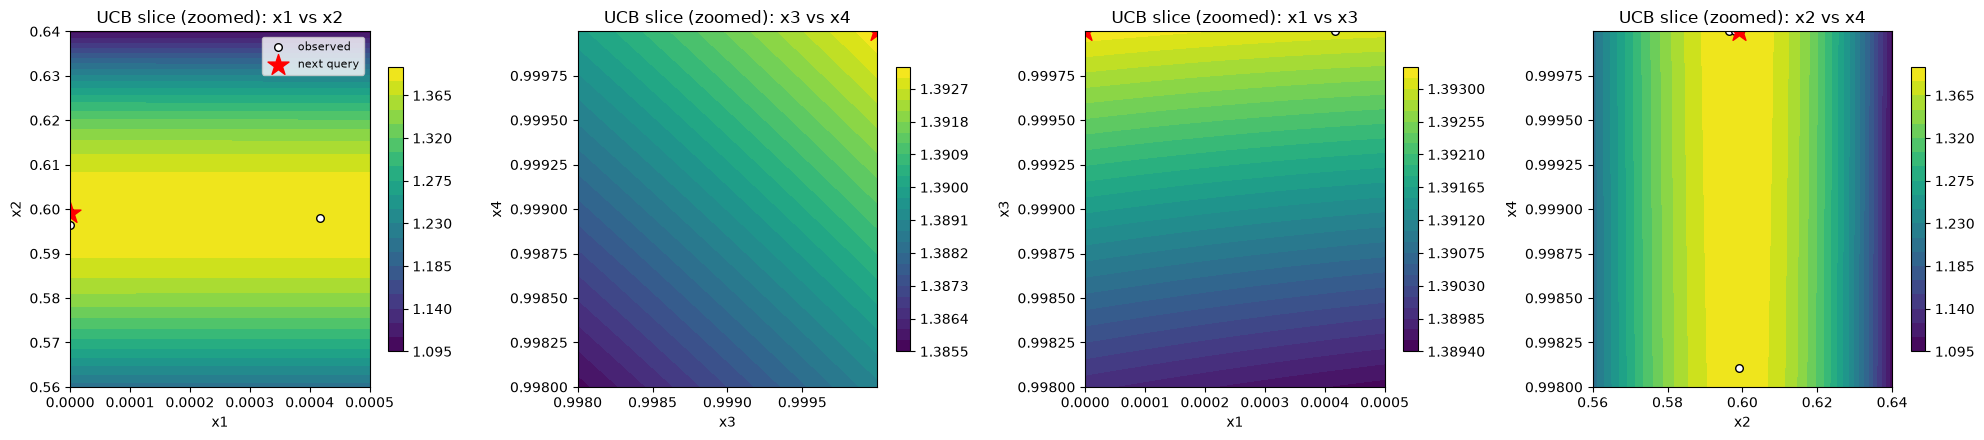

In [97]:
grid_n          = 60
pairs           = [(0, 1), (2, 3), (0, 2), (1, 3)]
fixed_point     = best_x_now.copy()

fig, axes       = plt.subplots(1, len(pairs), figsize = (5 * len(pairs), 4.5))
for ax, (d1, d2) in zip(axes, pairs):
    g1          = np.linspace(bounds[d1, 0], bounds[d1, 1], grid_n)
    g2          = np.linspace(bounds[d2, 0], bounds[d2, 1], grid_n)
    A, B        = np.meshgrid(g1, g2)
    grid_points = np.tile(fixed_point, (grid_n * grid_n, 1))
    grid_points[:, d1] = A.ravel()
    grid_points[:, d2] = B.ravel()

    scores = ucb_log_space(grid_points, beta).reshape(grid_n, grid_n)
    im = ax.contourf(A, B, scores, levels = 25, cmap = "viridis")
    ax.scatter(X[:, d1], X[:, d2], c = "white", edgecolor = "black", s = 30, label = "observed")
    ax.scatter(x_next[d1], x_next[d2], c = "red", marker = "*", s = 250, label = "next query")
    ax.set_xlim(bounds[d1, 0], bounds[d1, 1])
    ax.set_ylim(bounds[d2, 0], bounds[d2, 1])
    ax.set_xlabel(f"x{d1+1}")
    ax.set_ylabel(f"x{d2+1}")
    ax.set_title(f"UCB slice (zoomed): x{d1+1} vs x{d2+1}")
    fig.colorbar(im, ax = ax, shrink = 0.8)
axes[0].legend(loc = "upper right", fontsize = 8)
plt.tight_layout()
plt.show()

# Week 10: Calibration check after widening slightly

**Observation from Week 9's result:** The query landed at 1912.336, just below the current best (1915.052) and *inside* the GP's 95% confidence band (predicted mu = 1922.02, log-space std = 0.0095, back-transformed 95% CI [1886, 1958]). But the error (~9.7) is close in size to the reported std, a noticeably tighter miss than most earlier weeks relative to how confident the model claimed to be.

**Week 10 Strategy: Calibration check:** Re-running leave-one-out cross-validation on 29-point dataset shows ~95% CI coverage of only **82.8%**, below the 95% target and the second-lowest of the last three weeks (Week 8 was 75.0%, Week 7 was 81.5%). This is evidence that the surrogate is *somewhat overconfident across the dataset generally* in this heavily-exploited corner region.

**Changes:**
**1. Beta raised from 0.3 back up to 0.5:** A small, deliberate step back from pure exploitation, to make the acquisition function trust the (apparently slightly overconfident) predicted mean a little less and value uncertainty a little more.
**2. Search bounds loosened slightly on all four dimensions:** Rather than narrowing further: x1 upper bound relaxed 0.0005 -> 0.001, x2 window widened from [0.56, 0.64] to [0.55, 0.65], and x3/x4 lower bound relaxed from 0.998 to 0.997. x1, x3, x4 remain *pinned near* the boundary (that evidence, built up over Weeks 4-9, is still strong). This is a refinement of the same strategy, not a reversal of it.

In [109]:
# Sanity check: how well does the (previous-week) GP predict Week 9's actual query point?
mu_check, std_check = predict_yield(X_w9_new_point.reshape(1, -1))
print(f"GP prediction at Week 9's query : mu = {mu_check[0]:.3f}  (true y = {Y_w9_new_point[0]:.3f})")
print(f"Error (true - predicted)        : {Y_w9_new_point[0] - mu_check[0]:.3f}")

# Re-running RBF vs Matern comparison on the updated (29-point) dataset
kernel_matern_w10 = ConstantKernel(1.0, (1e-2, 1e2)) * Matern(length_scale = [1.0] * 4, length_scale_bounds = (1e-2, 1e2), nu = 1.5) \
                    + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-5, 1e0))
gpr_matern_w10 = GaussianProcessRegressor(kernel = kernel_matern_w10, normalize_y = False, n_restarts_optimizer = 10, random_state = 42)
gpr_matern_w10.fit(X_s, Y_s)

lml_rbf_w10    = gpr.log_marginal_likelihood(gpr.kernel_.theta)
lml_matern_w10 = gpr_matern_w10.log_marginal_likelihood(gpr_matern_w10.kernel_.theta)
print(f"\nWeek 10 RBF    LML: {lml_rbf_w10:.3f}")
print(f"Week 10 Matern LML: {lml_matern_w10:.3f}")
print("Kernel choice unchanged: RBF" if lml_rbf_w10 >= lml_matern_w10 else "Kernel choice changed: Matern")

# LOO-CV re-check 
rmse_gp_w10, coverage_gp_w10, _ = loo_cv_gp(X, Y, kernel_type = "rbf")
print(f"\nWeek 10 GP LOO-CV RMSE             : {rmse_gp_w10:.3f}  (Week 9 was {rmse_gp_w9:.3f})")
print(f"Week 10 GP LOO-CV ~95% CI coverage : {coverage_gp_w10*100:.1f}%  (Week 9 was {coverage_gp_w9*100:.1f}%, target 95%)")
print("-> Coverage is below target: the surrogate is somewhat overconfident in this region. Response: widen beta and bounds slightly (below),")
print("   rather than narrowing further, even though x1/x3/x4-pinned + x2-free remains the core strategy.")

# Widening beta (0.3 -> 0.5) and loosen bounds slightly on all 4 dims
best_idx   = np.argmax(Y)
best_x_now = X[best_idx]                               # still Week 7's point (current best)

lb = np.array([0.0  , 0.55, 0.997, 0.997])             # x3/x4 lower bound relaxed 0.998 -> 0.997, x2 widened 0.56 -> 0.55
ub = np.array([0.001, 0.65, 0.999999, 0.999999])       # x1 upper bound relaxed 0.0005 -> 0.001, x2 widened 0.64 -> 0.65
bounds = np.vstack([lb, ub]).T
print("\nWeek 10 search bounds (x1/x3/x4 still pinned near boundary but slightly looser, x2 free and slightly wider):\n", bounds)

beta = 0.5                                              # 0.3 -> 0.5 (acknowledge surrogate overconfidence, less pure exploitation)

result_rbf_w10    = bayesian_optimization_step(X, Y, bounds, beta = beta, kernel_type = "rbf")
result_matern_w10b = bayesian_optimization_step(X, Y, bounds, beta = beta, kernel_type = "matern")
print(f"\nWeek 10 RBF    LML: {result_rbf_w10['log_marginal_likelihood']:.3f}")
print(f"Week 10 Matern LML: {result_matern_w10b['log_marginal_likelihood']:.3f}")

final_w10 = result_matern_w10b if result_matern_w10b["log_marginal_likelihood"] > result_rbf_w10["log_marginal_likelihood"] else result_rbf_w10

gpr             = final_w10["gpr"]
X_scaler        = final_w10["X_scaler"]
Y_mean          = final_w10["Y_mean"]
Y_std           = final_w10["Y_std"]
x_next          = final_w10["x_next"]
pred_mu         = final_w10["mu_next"]
pred_std_log    = final_w10["std_next"]
ucb_next        = final_w10["ucb_next"]

print(f"\nWeek 10 chosen kernel       : {final_w10['kernel_type']}")
print(f"Suggested next Query Point  : {np.round(x_next, 6)}")
print(f"Predicted Mean (mu)         : {pred_mu:.4f}")
print(f"Predicted Std (sigma, log)  : {pred_std_log:.4f}")
print(f"UCB Score                   : {ucb_next:.4f}")

GP prediction at Week 9's query : mu = 1911.991  (true y = 1912.336)
Error (true - predicted)        : 0.345

Week 10 RBF    LML: -21.661
Week 10 Matern LML: -23.771
Kernel choice unchanged: RBF

Week 10 GP LOO-CV RMSE             : 464.330  (Week 9 was 464.330)
Week 10 GP LOO-CV ~95% CI coverage : 82.8%  (Week 9 was 82.8%, target 95%)
-> Coverage is below target: the surrogate is somewhat overconfident in this region. Response: widen beta and bounds slightly (below),
   rather than narrowing further, even though x1/x3/x4-pinned + x2-free remains the core strategy.

Week 10 search bounds (x1/x3/x4 still pinned near boundary but slightly looser, x2 free and slightly wider):
 [[0.       0.001   ]
 [0.55     0.65    ]
 [0.997    0.999999]
 [0.997    0.999999]]

Week 10 RBF    LML: -21.661
Week 10 Matern LML: -23.771

Week 10 chosen kernel       : rbf
Suggested next Query Point  : [0.       0.599863 0.999999 0.999999]
Predicted Mean (mu)         : 1911.8853
Predicted Std (sigma, log)  : 0.

# Week 10: UCB Visualisation

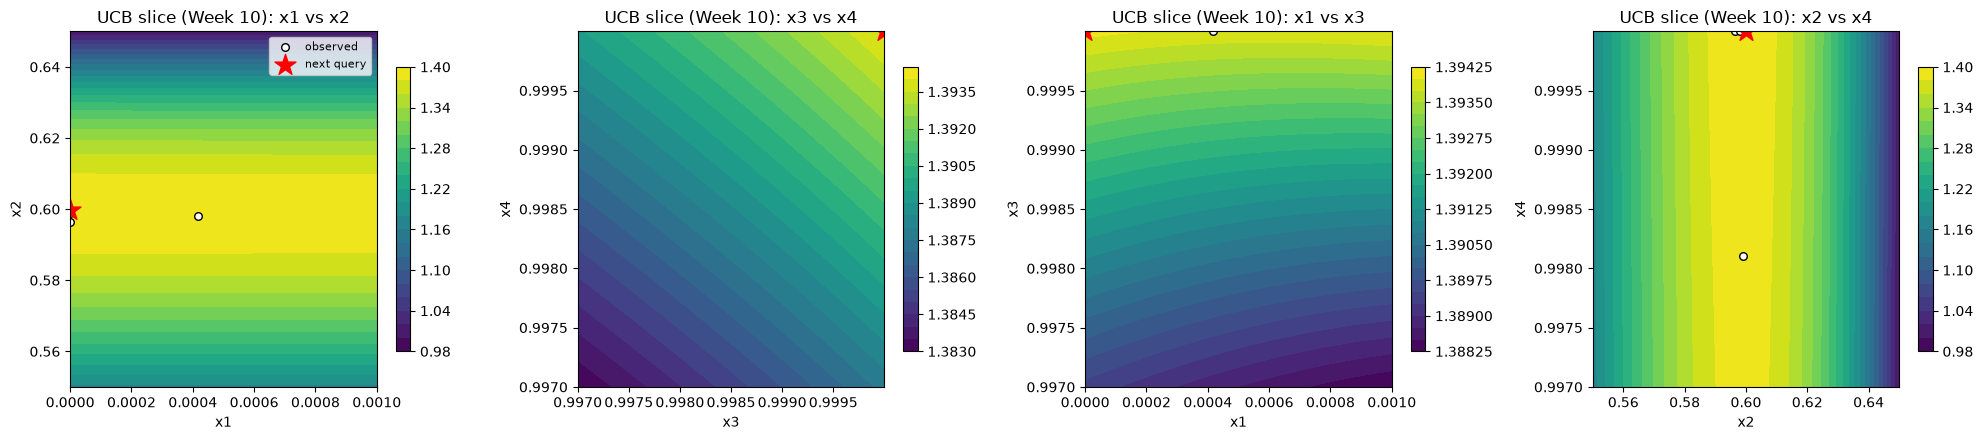

In [112]:
grid_n          = 60
pairs           = [(0, 1), (2, 3), (0, 2), (1, 3)]
fixed_point     = best_x_now.copy()

fig, axes       = plt.subplots(1, len(pairs), figsize = (5 * len(pairs), 4.5))
for ax, (d1, d2) in zip(axes, pairs):
    g1          = np.linspace(bounds[d1, 0], bounds[d1, 1], grid_n)
    g2          = np.linspace(bounds[d2, 0], bounds[d2, 1], grid_n)
    A, B        = np.meshgrid(g1, g2)
    grid_points = np.tile(fixed_point, (grid_n * grid_n, 1))
    grid_points[:, d1] = A.ravel()
    grid_points[:, d2] = B.ravel()

    scores = ucb_log_space(grid_points, beta).reshape(grid_n, grid_n)
    im = ax.contourf(A, B, scores, levels = 25, cmap = "viridis")
    ax.scatter(X[:, d1], X[:, d2], c = "white", edgecolor = "black", s = 30, label = "observed")
    ax.scatter(x_next[d1], x_next[d2], c = "red", marker = "*", s = 250, label = "next query")
    ax.set_xlim(bounds[d1, 0], bounds[d1, 1])
    ax.set_ylim(bounds[d2, 0], bounds[d2, 1])
    ax.set_xlabel(f"x{d1+1}")
    ax.set_ylabel(f"x{d2+1}")
    ax.set_title(f"UCB slice (Week 10): x{d1+1} vs x{d2+1}")
    fig.colorbar(im, ax = ax, shrink = 0.8)
axes[0].legend(loc = "upper right", fontsize = 8)
plt.tight_layout()
plt.show()

# Portal Submission 

In [118]:
# Format as required by the capstone portal: x1-x2 (6 decimal places)
def format_submission(x):
    return "-".join(f"{v:.6f}" for v in x)

submission_str = format_submission(x_next)
print("Points to be submitted(Week 1)  :",'0.037439-0.014236-0.070689-0.986304')
print("Points to be submitted(Week 2)  :",'0.000000-0.596480-0.999999-0.999999')
print("Points to be submitted(Week 3)  :",'0.000000-0.796480-0.999999-0.999999')
print("Points to be submitted(Week 4)  :",'0.018201-0.598992-0.955729-0.998108')
print("Points to be submitted(Week 5)  :",'0.100000-0.593535-0.899999-0.911213')
print("Points to be submitted(Week 6)  :",'0.437120-0.835366-0.700265-0.312367')
print("Points to be submitted(Week 7)  :",'0.000000-0.599413-0.999999-0.999999')
print("Points to be submitted(Week 8)  :",'0.000000-0.599054-0.999999-0.989999')
print("Points to be submitted(Week 9)  :",'0.000418-0.598066-0.999999-0.999999')
print(f"Points to be submitted(Week 10) : {submission_str}") 

Points to be submitted(Week 1)  : 0.037439-0.014236-0.070689-0.986304
Points to be submitted(Week 2)  : 0.000000-0.596480-0.999999-0.999999
Points to be submitted(Week 3)  : 0.000000-0.796480-0.999999-0.999999
Points to be submitted(Week 4)  : 0.018201-0.598992-0.955729-0.998108
Points to be submitted(Week 5)  : 0.100000-0.593535-0.899999-0.911213
Points to be submitted(Week 6)  : 0.437120-0.835366-0.700265-0.312367
Points to be submitted(Week 7)  : 0.000000-0.599413-0.999999-0.999999
Points to be submitted(Week 8)  : 0.000000-0.599054-0.999999-0.989999
Points to be submitted(Week 9)  : 0.000418-0.598066-0.999999-0.999999
Points to be submitted(Week 10) : 0.000000-0.599863-0.999999-0.999999


# Convergence & parallel-coordinates plots

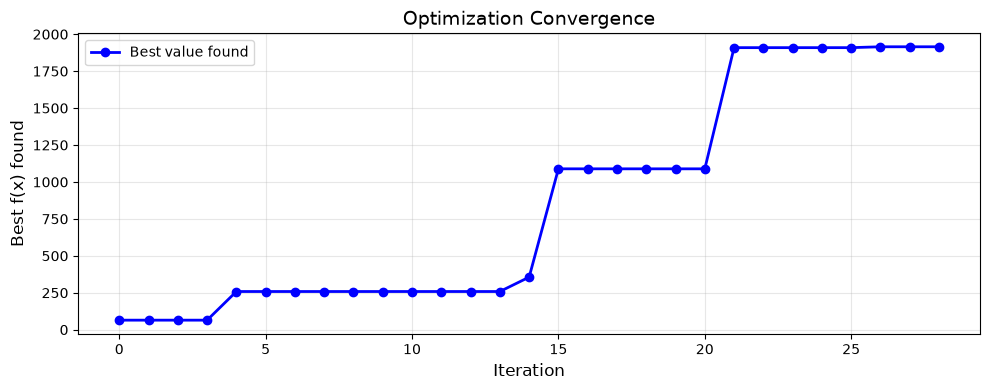

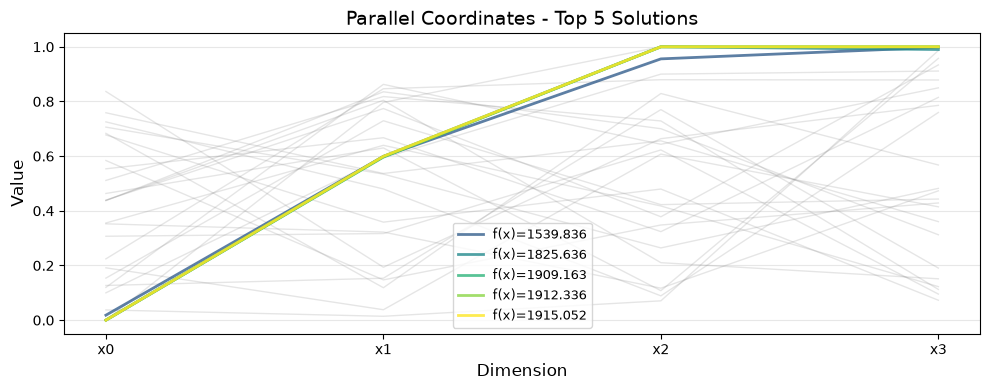

In [121]:
best_so_far   = []
running_best  = -np.inf
for val in Y:
    running_best = max(running_best, val)
    best_so_far.append(running_best)

plot_convergence(range(len(best_so_far)), best_so_far)
plt.show()

plot_parallel_coordinates(X, Y, n_best = 5)
plt.show()

# Weekly Dashboard

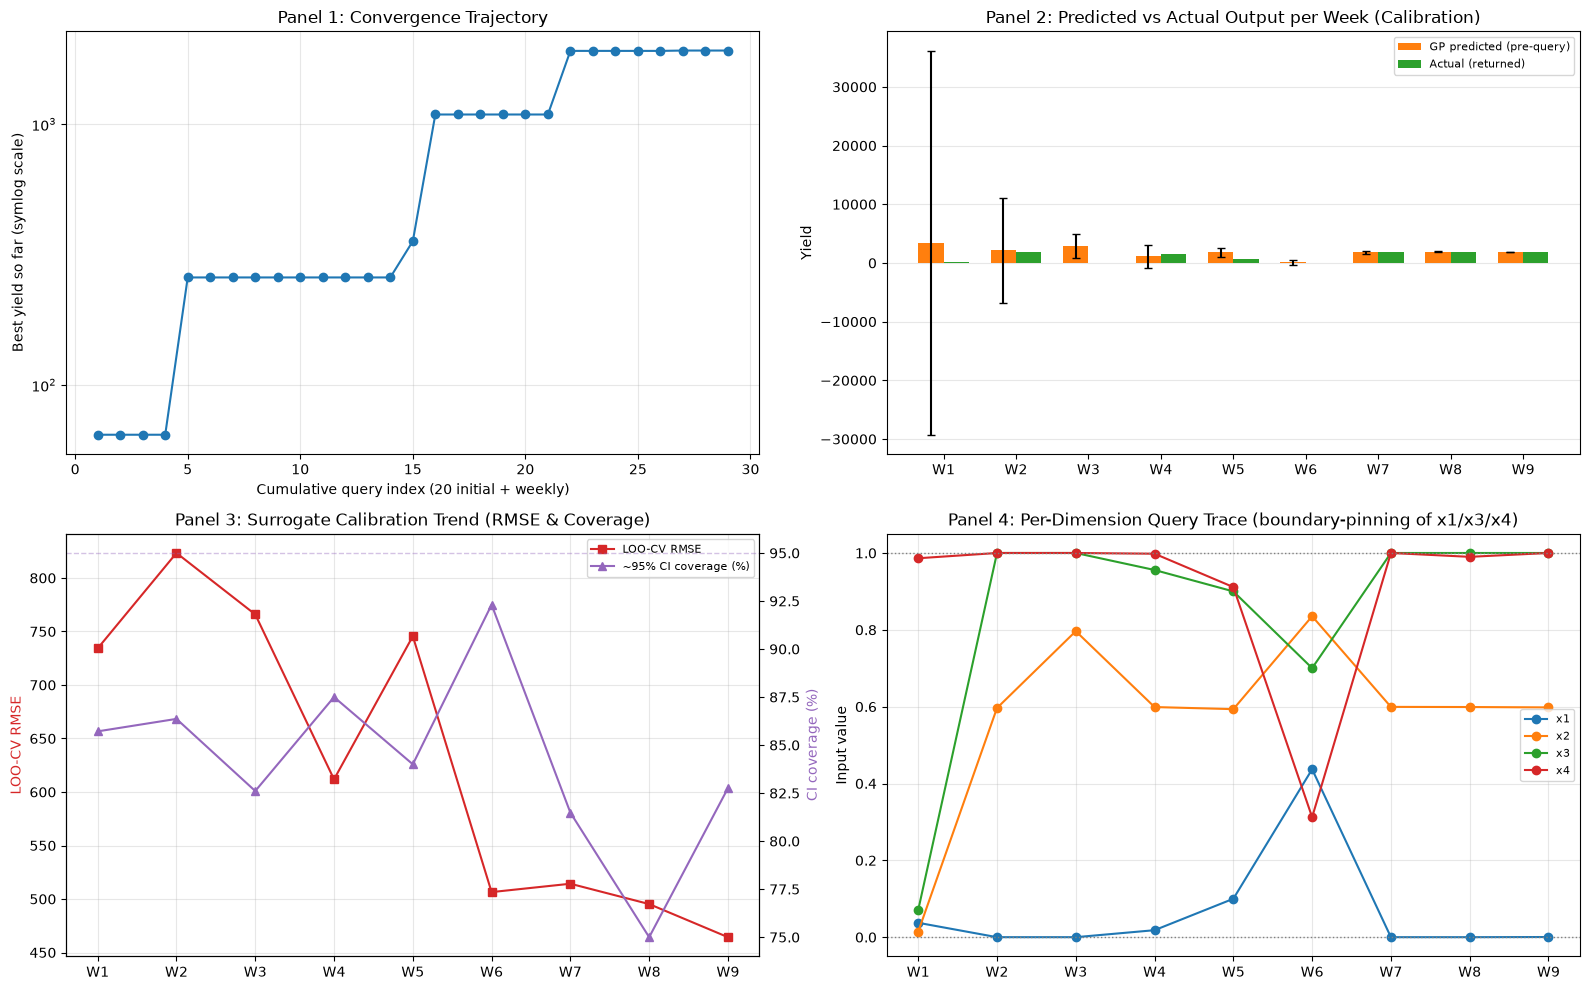

Week 9 calibration check: predicted 1922.02 vs actual 1912.34
LOO-CV coverage trend (Week1->Week9): [np.float64(85.7), np.float64(86.4), np.float64(82.6), np.float64(87.5), np.float64(84.0), np.float64(92.3), np.float64(81.5), np.float64(75.0), np.float64(82.8)]


In [126]:
import matplotlib.gridspec as gridspec

week_labels   = ["W1","W2","W3","W4","W5","W6","W7","W8","W9"]
week_x_points = [X_w1_new_point, X_w2_new_point, X_w3_new_point, X_w4_new_point, X_w5_new_point,
                  X_w6_new_point, X_w7_new_point, X_w8_new_point, X_w9_new_point]
week_y_actual = [Y_w1_new_point[0], Y_w2_new_point[0], Y_w3_new_point[0], Y_w4_new_point[0], Y_w5_new_point[0],
                  Y_w6_new_point[0], Y_w7_new_point[0], Y_w8_new_point[0], Y_w9_new_point[0]]

# Panel 2 data: what would the FINAL (Week 10) GP have predicted at each week's actual query,
# using only the data available *before* that week's query was made (fit incrementally, LOO-in-time)
X_running, Y_running = X0.copy(), Y0.copy()
week_y_pred, week_y_pred_std = [], []
for xq, yq in zip(week_x_points, week_y_actual):
    Xsc_r = StandardScaler(); Xs_r = Xsc_r.fit_transform(X_running)
    Ylog_r = signed_log1p(Y_running); ym_r, ys_r = Ylog_r.mean(), Ylog_r.std()
    Ys_r = (Ylog_r - ym_r) / ys_r
    k_r = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale=[1.0]*4, length_scale_bounds=(1e-2, 1e2)) + WhiteKernel(1e-2, (1e-5, 1e0))
    g_r = GaussianProcessRegressor(kernel=k_r, normalize_y=False, n_restarts_optimizer=5, random_state=42)
    g_r.fit(Xs_r, Ys_r)
    mu_s, std_s = g_r.predict(Xsc_r.transform(xq.reshape(1, -1)), return_std=True)
    mu_log = mu_s[0]*ys_r + ym_r
    week_y_pred.append(inverse_signed_log1p(mu_log))
    week_y_pred_std.append(abs(inverse_signed_log1p(mu_log + std_s[0]*ys_r) - inverse_signed_log1p(mu_log)))
    X_running = np.vstack([X_running, xq]); Y_running = np.append(Y_running, yq)

# Panel 3 data: LOO-CV RMSE / coverage trend, recomputed cumulatively week-by-week
rmse_trend, coverage_trend = [], []
X_c, Y_c = X0.copy(), Y0.copy()
for xq, yq in zip(week_x_points, week_y_actual):
    X_c = np.vstack([X_c, xq]); Y_c = np.append(Y_c, yq)
    r, cov, _ = loo_cv_gp(X_c, Y_c, kernel_type="rbf")
    rmse_trend.append(r); coverage_trend.append(cov*100)

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig)

# --- Panel 1: Convergence trajectory (best-so-far), log-scale where positive ---
ax1 = fig.add_subplot(gs[0, 0])
running_best = []
best_so_far  = -np.inf
for v in Y:
    best_so_far = max(best_so_far, v)
    running_best.append(best_so_far)
ax1.plot(range(1, len(running_best)+1), running_best, marker="o", color="#1f77b4")
ax1.set_yscale("symlog")
ax1.set_xlabel("Cumulative query index (20 initial + weekly)")
ax1.set_ylabel("Best yield so far (symlog scale)")
ax1.set_title("Panel 1: Convergence Trajectory")
ax1.grid(alpha=0.3)

# --- Panel 2: Predicted (pre-query) vs Actual yield, per week ---
ax2 = fig.add_subplot(gs[0, 1])
x_pos = np.arange(len(week_labels))
width = 0.35
ax2.bar(x_pos - width/2, week_y_pred, width, yerr=week_y_pred_std, label="GP predicted (pre-query)", color="#ff7f0e", capsize=3)
ax2.bar(x_pos + width/2, week_y_actual, width, label="Actual (returned)", color="#2ca02c")
ax2.set_xticks(x_pos); ax2.set_xticklabels(week_labels)
ax2.set_ylabel("Yield")
ax2.set_title("Panel 2: Predicted vs Actual Output per Week (Calibration)")
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3, axis="y")

# --- Panel 3: LOO-CV RMSE & coverage trend ---
ax3  = fig.add_subplot(gs[1, 0])
ax3b = ax3.twinx()
ax3.plot(week_labels, rmse_trend, marker="s", color="#d62728", label="LOO-CV RMSE")
ax3b.plot(week_labels, coverage_trend, marker="^", color="#9467bd", label="~95% CI coverage (%)")
ax3b.axhline(95, color="#9467bd", linestyle="--", alpha=0.4, linewidth=1)
ax3.set_ylabel("LOO-CV RMSE", color="#d62728")
ax3b.set_ylabel("CI coverage (%)", color="#9467bd")
ax3.set_title("Panel 3: Surrogate Calibration Trend (RMSE & Coverage)")
ax3.grid(alpha=0.3)
lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3b.get_legend_handles_labels()
ax3.legend(lines1+lines2, labels1+labels2, fontsize=8, loc="upper right")

# --- Panel 4: Per-dimension trace across weekly queries (boundary-pinning story) ---
ax4 = fig.add_subplot(gs[1, 1])
dim_names  = ["x1", "x2", "x3", "x4"]
dim_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
week_matrix = np.array(week_x_points)
for d in range(4):
    ax4.plot(week_labels, week_matrix[:, d], marker="o", label=dim_names[d], color=dim_colors[d])
ax4.axhline(0.0, color="grey", linestyle=":", linewidth=1)
ax4.axhline(0.999999, color="grey", linestyle=":", linewidth=1)
ax4.set_ylabel("Input value")
ax4.set_title("Panel 4: Per-Dimension Query Trace (boundary-pinning of x1/x3/x4)")
ax4.legend(fontsize=8)
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Week 9 calibration check: predicted", round(week_y_pred[-1],2), "vs actual", round(week_y_actual[-1],2))
print("LOO-CV coverage trend (Week1->Week9):", [round(c,1) for c in coverage_trend])